## imports and installations

In [ ]:
!pip install pyspoc

In [2]:
!pip install pyspoc[all]

In [3]:
%env PYDEVD_DISABLE_FILE_VALIDATION=1

env: PYDEVD_DISABLE_FILE_VALIDATION=1


In [4]:
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

In [5]:
# install some prerequisite packages for pyspi
!pip install oct2py
!pip install jpype1

In [6]:
from pyspoc import Calculator, Config

octave not found, please see README
Octave not available: octave not found, please see README
Starting JVM with java class C:\Rishi\Maths\Research Project\py-spoc\pyspoc/lib/jidt/infodynamics.jar.
Jpype JVM not available: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


In [7]:
# import other helper libraries
import pandas as pd
import numpy as np

In [8]:
!pip install ucimlrepo

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
communities_and_crime_unnormalized = fetch_ucirepo(id=211) 
  
# data (as pandas dataframes) 
X = communities_and_crime_unnormalized.data.features 
print(X)

     State    pop  perHoush  pctBlack  pctWhite  pctAsian  pctHisp  pct12-21  \
0       NJ  11980      3.10      1.37     91.78      6.50     1.88     12.47   
1       PA  23123      2.82      0.80     95.57      3.44     0.85     11.01   
2       OR  29344      2.43      0.74     94.33      3.43     2.35     11.36   
3       NY  16656      2.40      1.70     97.35      0.50     0.70     12.55   
4       MN  11245      2.76      0.53     89.16      1.17     0.52     24.46   
...    ...    ...       ...       ...       ...       ...      ...       ...   
2210    CA  56216      3.07      6.87     61.68     15.23    29.86     15.46   
2211    LA  12251      2.68     21.18     76.65      1.52     1.29     17.36   
2212    CA  32824      2.46      0.52     92.62      0.98    11.00     11.81   
2213    TX  13547      2.89      3.37     69.91      0.90    62.11     17.16   
2214    CA  28898      2.61      2.39     71.27      9.09    24.43     12.99   

      pct12-29  pct16-24  ...  policAve

## data generation

currently just random integers

In [10]:
# generate a random dataframe
df = pd.DataFrame(np.random.randint(0,100,size=(100, 4)), columns=list('ABCD'))

## Simple Example in PySS: using **Statistics** and **Reducers**

https://github.com/garry-cotton/pyss


In [11]:
# create a simple YAML config for pyss

# we first configure the 'Statistics' we want to use
# in this eg, we use the Covariance and the KendallTau correlation coefficient

# we then configure the 'Reducers' we want to use
# in this eg, we use the SingularValues and the Determinant

# for each Reducer function, we determine which Statistic to apply it to reduce

yaml_str_stat_reduce = """
Statistics:
  pyspoc.statistics.basic:
    # Covariance
    Covariance:
      schemes:
        cov:
          estimator: EmpiricalCovariance

    # Kendall Tau correlation coefficient
    KendallTau:
      schemes:
        sq:
          squared: True

        standard:
          squared: False

Reducers:
  pyspoc.reducers.basic:
    SingularValues:
      Statistics:
        - pyspoc.statistics.basic.Covariance.cov
        - pyspoc.statistics.basic.KendallTau.sq
        - pyspoc.statistics.basic.KendallTau.standard
      schemes:
        three:
          num_values: 3

    Determinant:
      Statistics:
        - pyspoc.statistics.basic.Covariance.cov
      schemes:
        scaled:
          scaled: True

        non-scaled:
          scaled: False
"""

In [12]:
yaml_str_stat_reduce = """ReducedStatistics:
  C:/Rishi/Maths/Research Project/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py:
    DistanceDistributionBasicSummarize:
      schemes:
        cosine_distrib_meancentroid:
          metric: cosine
          stats: 
            - std
            - mean
            - iqr
          point: global_mean_centroid
        euclidean_distrib_meancentroid:
          metric: euclidean
          stats: 
            - std
            - mean
            - iqr
          point: global_mean_centroid
        canberra_distrib_meancentroid:
          metric: canberra
          stats: 
            - std
            - mean
            - iqr
          point: global_mean_centroid
        cosine_skew_meancentroid:
          metric: cosine
          stats: 
            - skew
          point: global_mean_centroid
        euclidean_skew_meancentroid:
          metric: euclidean
          stats: 
            - skew
          point: global_mean_centroid
        canberra_kurt_meancentroid:
          metric: canberra
          stats: 
            - kurtosis
          point: global_mean_centroid
        cosine_kurt_meancentroid:
          metric: cosine
          stats: 
            - kurtosis
          point: global_mean_centroid
        euclidean_kurt_meancentroid:
          metric: euclidean
          stats: 
            - kurtosis
          point: global_mean_centroid
        canberra_kurt_meancentroid:
          metric: canberra
          stats: 
            - kurtosis
          point: global_mean_centroid
        cosine_distrib_pairwise:
          metric: cosine
          stats: 
            - std
            - mean
            - iqr
          point: all
        euclidean_distrib_pairwise:
          metric: euclidean
          stats: 
            - std
            - mean
            - iqr
          point: all
        canberra_distrib_pairwise:
          metric: canberra
          stats: 
            - std
            - mean
            - iqr
          point: all
        cosine_skew_pairwise:
          metric: cosine
          stats: 
            - skew
          point: all
        euclidean_skew_pairwise:
          metric: euclidean
          stats: 
            - skew
          point: all
        canberra_kurt_pairwise:
          metric: canberra
          stats: 
            - kurtosis
          point: all
        cosine_kurt_pairwise:
          metric: cosine
          stats: 
            - kurtosis
          point: all
        euclidean_kurt_pairwise:
          metric: euclidean
          stats: 
            - kurtosis
          point: all
        canberra_kurt_pairwise:
          metric: canberra
          stats: 
            - kurtosis
          point: all
    DistanceDistributionModesSummarize:
      schemes:
        corr_peaks_meancentroid:
          metric: correlation
          point: global_mean_centroid
          type: kde
        euclidean_peaks_meancentroid:
          metric: euclidean
          point: global_mean_centroid
          type: kde
        canberra_peaks_meancentroid:
          metric: canberra
          point: global_mean_centroid
          type: kde
        corr_peaks_pairwise:
          metric: correlation
          point: all
          type: kde
        euclidean_peaks_pairwise:
          metric: euclidean
          point: all
          type: kde
        canberra_peaks_pairwise:
          metric: canberra
          point: all
          type: kde
Statistics:
    pyspoc.statistics.basic:
        Covariance:
            schemes:
                empirical:
                    estimator: EmpiricalCovariance
Reducers:
  C:/Rishi/Maths/Research Project/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py:
    MaxCovPerFeature:
        schemes:
          max_min_median:
            stats: 
              - max
              - min
              - median
    EigenAMGMRatio:
      schemes:
        eigen_amgm:        
    EigenEntropy:
      schemes:
        eigen_entropy:"""

In [13]:
yaml_str_stat_reduce = """Statistics:
  pyspoc.statistics.causal:
    AdditiveNoiseModel:
      schemes:
        std: 
    ConditionalDistributionSimilarity:
      schemes:
        std:
    RegressionErrorCausalInference:
      schemes:
        std:
Reducers:
  pyspoc.reducers.basic:
    Diag:
      schemes:
        std:
          num_values: 2
    Trace:
      schemes:
        std: null
"""

In [14]:
yaml_str_stat_reduce = """
Statistics:
  pyspoc.statistics.basic:
    # Covariance
    Covariance:
      schemes:
        cov:
          estimator: EmpiricalCovariance

    # Kendall Tau correlation coefficient
    KendallTau:
      schemes:
        sq:
          squared: True

        standard:
          squared: False

Reducers:
  pyspoc.reducers.basic:
    SingularValues:
      Statistics:
        - pyspoc.statistics.basic.Covariance.cov
        - pyspoc.statistics.basic.KendallTau.sq
        - pyspoc.statistics.basic.KendallTau.standard
      schemes:
        three:
          num_values: 3

    Determinant:
      Statistics:
        - pyspoc.statistics.basic.Covariance.cov
      schemes:
        scaled:
          scaled: True

        non-scaled:
          scaled: False
"""

In [15]:
# copy the randomly generated dataframe
my_dataset = df.copy()

# set a name for the config
my_config_name = "test_config_yml"
# create a Config class object
cfg = Config.from_yaml(my_config_name, yaml_str_stat_reduce)
# pass the dataframe or numpy array
# constructs a 'Calculator' instance
calc = Calculator(my_dataset, normalise=False)
# run the compute function - applies functions in the config (i.e. in Statistic and Reducer) to the Data
calc.compute(cfg)
# view results
calc.results.T 

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic loaded successfully.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic loaded successfully.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 14.03it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 138.20it/s]


Calculation complete. Time taken: 0.2388s


0
Statistic                                   Reducer                                                   
pyspoc.statistics.basic.Covariance.cov      pyspoc.reducers.basic.SingularValues.three_1  1.006045e+03
                                            pyspoc.reducers.basic.SingularValues.three_2  9.359836e+02
                                            pyspoc.reducers.basic.SingularValues.three_3  6.545117e+02
                                            pyspoc.reducers.basic.Determinant.scaled      9.494659e-24
                                            pyspoc.reducers.basic.Determinant.non-scaled  3.245341e+11
pyspoc.statistics.basic.KendallTau.sq       pyspoc.reducers.basic.SingularValues.three_1  1.024871e+00
                                            pyspoc.reducers.basic.SingularValues.three_2  1.004043e+00
                                            pyspoc.reducers.basic.SingularValues.three_3  9.953464e-01
pyspoc.statistics.basic.KendallTau.standard pyspoc.reducers.basic.SingularValues.three_1  1.156773e+00
                                            pyspoc.reducers.basic.SingularValues.three_2  1.071123e+00
                                            pyspoc.reducers.basic.SingularValues.three_3  9.703394e-01

In [16]:
REDUCERS = list(calc.results.columns.values)
REDUCERS

[('pyspoc.statistics.basic.Covariance.cov',
  'pyspoc.reducers.basic.SingularValues.three_1'),
 ('pyspoc.statistics.basic.Covariance.cov',
  'pyspoc.reducers.basic.SingularValues.three_2'),
 ('pyspoc.statistics.basic.Covariance.cov',
  'pyspoc.reducers.basic.SingularValues.three_3'),
 ('pyspoc.statistics.basic.Covariance.cov',
  'pyspoc.reducers.basic.Determinant.scaled'),
 ('pyspoc.statistics.basic.Covariance.cov',
  'pyspoc.reducers.basic.Determinant.non-scaled'),
 ('pyspoc.statistics.basic.KendallTau.sq',
  'pyspoc.reducers.basic.SingularValues.three_1'),
 ('pyspoc.statistics.basic.KendallTau.sq',
  'pyspoc.reducers.basic.SingularValues.three_2'),
 ('pyspoc.statistics.basic.KendallTau.sq',
  'pyspoc.reducers.basic.SingularValues.three_3'),
 ('pyspoc.statistics.basic.KendallTau.standard',
  'pyspoc.reducers.basic.SingularValues.three_1'),
 ('pyspoc.statistics.basic.KendallTau.standard',
  'pyspoc.reducers.basic.SingularValues.three_2'),
 ('pyspoc.statistics.basic.KendallTau.standard'

## Simple Example in PySS: using **ReducedStatistics**

https://github.com/garry-cotton/pyss

to illustrate the use of the ReducedStatistics, we use two PCA-based statistics and one inherited from the Statistics class (since any Statistic can be used as a ReducedStatistic also)

more Statistics, Reducers, and ReducedStatistics can be added similarly to how it's done for ReducedStatistics in ```pyss/rstatistics/test.py```

In [17]:
yaml_reducedStat = """
ReducedStatistics:
  pyspoc.rstatistics.pca:
    PCAVarianceExplainedRatio:
      schemes:
        std:
          components:
            - 2
            - 4

    PCAEigenVectors:
      schemes:
        std:
          principal_vectors:
            - 1
            - 3

  pyspoc.rstatistics.test:
    ReducedCovarianceTest:
      schemes:
        cov:
          estimator: EmpiricalCovariance

"""

In [18]:
# copy the randomly generated dataframe
my_dataset_rs = df.copy()

# set a name for the config
my_config_name_rs = "test_config_yml_rs"
# create a Config class object
cfg_rs = Config.from_yaml(my_config_name_rs, yaml_reducedStat)
# pass the dataframe or numpy array
# constructs a 'Calculator' instance
calc_rs = Calculator(my_dataset_rs)

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.rstatistics.pca loaded successfully.
    ✔ ReducedStatistic PCAVarianceExplainedRatio scheme 'std' added successfully.
    ✔ ReducedStatistic PCAEigenVectors scheme 'std' added successfully.
  ✔ Module pyspoc.rstatistics.test loaded successfully.
    ✔ ReducedStatistic ReducedCovarianceTest scheme 'cov' added successfully.
Normalising the dataset using StandardScaler 



In [19]:
# run the compute function - applies functions in the config (i.e. in Statistic and Reducer) to the Data
calc_rs.compute(cfg_rs)

Processing [None: pyspoc.rstatistics.test.ReducedCovarianceTest.cov]: 100%|██████████| 3/3 [00:00<00:00, 106.35it/s]


Calculation complete. Time taken: 0.0292s


In [20]:
# view results
calc_rs.results.T

0
Statistic                                          Reducer          
pyspoc.rstatistics.pca.PCAVarianceExplainedRati... self_1   0.280231
                                                   self_2   0.174015
pyspoc.rstatistics.pca.PCAEigenVectors.std         self_1  -0.686868
                                                   self_2  -0.714333
                                                   self_3  -0.099915
                                                   self_4  -0.089202
                                                   self_5   0.324582
                                                   self_6  -0.336338
                                                   self_7  -0.486013
                                                   self_8   0.738455
pyspoc.rstatistics.test.ReducedCovarianceTest.cov  self_1   1.000000
                                                   self_2   1.000000
                                                   self_3   1.000000
                                                   self_4   1.000000

##Functions to Load and manipulate dataframe as appropriate

In [21]:
# Importing necessary libraries for data processing
import numpy as np
import pandas as pd
import scipy.stats
from typing import List, Dict, Union, Callable, Optional, Any, Tuple
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.figure import Figure
from tqdm.notebook import tqdm
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import matplotlib.pyplot as plt

In [22]:
def strip_common_prefix(data):
    # prefix = "C:/Rishi/Maths/Research Project/py-spoc/working_analyses/hjResearch_2025/summary_stats/"
    # result = []
    # for x in data:
    #     if isinstance(x, tuple):
    #         # Remove prefix from each element in the tuple
    #         result.append(tuple(
    #             xi.replace(prefix, '') if isinstance(xi, str) else xi
    #             for xi in x
    #         ))
    #     elif isinstance(x, str):
    #         result.append(x.replace(prefix, ''))
    #     else:
    #         result.append(x)
    return data

In [23]:
def load_data(df) -> pd.DataFrame:
    """
    Drop non-numeric columns and convert to numeric.
    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the data to change.
    Returns:
    --------
    pd.DataFrame
        The loaded data.
    """
    if type(df) is not pd.DataFrame:
        df = pd.DataFrame(df)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_cols]  # Keep only numeric columns
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()

    return df


def normalize_data(data: pd.DataFrame, method: str = 'z-score') -> pd.DataFrame:
    """
    Normalize the data using the specified method.

    Parameters:
    -----------
    data : pd.DataFrame
        The data to normalize.
    method : str, optional
        The method to use for scaling. Options are:
        - 'z-score': Z-Score Normalization (StandardScaler)
        - 'min-max': Min-Max Normalization (MinMaxScaler)
        - 'robust': Robust Scaling using median and IQR (RobustScaler)

    Returns:
    --------
    pd.DataFrame
        The normalized data.
    """
    normalized = data.copy()

    # Select the appropriate scaler based on the method
    if method == 'z-score':
        scaler = StandardScaler()
    elif method == 'min-max':
        scaler = MinMaxScaler()
    elif method == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Unknown normalization method: {method}. "
                         f"Choose from 'z-score', 'min-max', or 'robust'.")

    # Apply the scaler to the data
    normalized_values = scaler.fit_transform(normalized)
    normalized = pd.DataFrame(normalized_values,
                             index=normalized.index,
                             columns=normalized.columns)

    return normalized


def shuffle_data(df: pd.DataFrame, random_seed=None) -> pd.DataFrame:
    """
    Returns a new DataFrame with each column's elements shuffled independently.

    Parameters:
    - df: The input pandas DataFrame.
    - random_seed: Optional seed for reproducibility.

    Returns:
    - A new DataFrame with columns shuffled.
    """
    rng = np.random.default_rng(seed=random_seed)
    return pd.DataFrame(
        [rng.permutation(df[col]) for col in df.columns],
        index=df.columns,
        columns=df.index
    ).T

def perturb_dataframe(df, scale_factor=0.1, random_seed=None):
    """    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing numeric values
    scale_factor : float, default=0.1
        Scaling factor for the perturbation
    random_seed : int, optional
        Random seed for reproducible results
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with perturbed values
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Calculate column variances
    col_variances = df.var(axis=0, ddof=1)
    col_variances = np.maximum(col_variances, 1e-6)  
    
    # Calculate perturbation standard deviations
    perturbation_stds = scale_factor * np.sqrt(col_variances)
    
    # Create perturbation matrix
    perturbations = np.random.normal(0, 1, size=df.shape)
    
    # Scale perturbations by column-specific standard deviations
    for j in range(df.shape[1]):
        perturbations[:, j] *= perturbation_stds.iloc[j]
    
    # Add perturbations to original data
    perturbed_df = df + perturbations
    
    return perturbed_df

##Applying reducers to dataframe

In [24]:
#defining reducers
REDUCERS = list(calc.results.columns.values)
for reducer in REDUCERS:
    print(calc.results[reducer].values[0])

1006.0452231269489
935.983618630101
654.5117230354613
9.494659084195604e-24
324534081887.4647
1.0248712861064673
1.004042570050512
0.9953463502197153
1.156773299084256
1.0711228156658228
0.9703393829367274


In [25]:
def apply_reducer(calc, reducer) -> float:
    """
    Apply a specific reducer to a matrix and get a value, useful for iterating
    Parameters:
    -----------
    calc : Calculator
        The calculator instance.
    reducer : gets reducer value from calc.results

    Returns:
    --------
    float
        The reduced value.
    """
    return calc.results[reducer].values[0]


def pyspi_calc(df,config_name, yaml, normalize=None, shuffle=False, perturb=False,scale_factor=0.1,random_seed=None):
    """
    Parameters:
    - df: DataFrame containing the data to change
    - config_name: Name of the configuration file
    - yaml: YAML string for configuration
    - normalize: Method to normalize data (default: None)
    - shuffle: Whether to randomly shuffle rows (default: False)
    - random_seed: Seed for reproducible shuffling (default: None)

    Returns:
    - Calc results table
    """
    # Load data 
    df = load_data(df)

    # If shuffle is requested, shuffle the data
    if shuffle:
        df = shuffle_data(df, random_seed=random_seed)

    if normalize is not None:
        df = normalize_data(df, method=normalize)
    # If perturb is requested, add random noise to the data
    if perturb:
        df = perturb_dataframe(df, scale_factor=scale_factor, random_seed=random_seed)
    cfg = Config.from_yaml(config_name, yaml)
    # Use Calculator class to compute the statistics
    # pass the dataframe or numpy array
    # constructs a 'Calculator' instance
    calc = Calculator(df, normalise=False)
    # run the compute function - applies functions in the config (i.e. in Statistic and Reducer) to the Data
    calc.compute(cfg)
    return calc.results

In [26]:
def permutation_test(
    df: pd.DataFrame,
    config_name,
    yaml,
    calc,
    n_permutations: int = 1000,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    save_permutation_data: bool = True,
    orig_calc_table: Optional[Dict] = None,
) -> Dict[str, Dict[str, Any]]:
    """
    Perform a permutation test to assess statistical significance and calculate variance.
    """
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    # Use provided orig_calc_table or compute
    if orig_calc_table is None:
        orig_calc_table = pyspi_calc(df, config_name, yaml, normalize=normalize)

    orig_results = {
        reducer: orig_calc_table[reducer].values[0] for reducer in REDUCERS
    }
    
    perm_values = {reducer: [] for reducer in REDUCERS}

    # Run permutations with progress bar
    iter_range = tqdm(range(n_permutations))
    for i in iter_range:
        # Use different random seed for each perm
        perm_seed = None if random_seed is None else random_seed + i + 1
        # Get shuffled data statistics
        perm_calc_table = pyspi_calc(df, config_name,yaml, normalize=normalize, shuffle=True, random_seed=perm_seed)

        for reducer in REDUCERS:
            perm_value = perm_calc_table[reducer].values[0]
            # Append the value to the list
            perm_values[reducer].append(perm_value)

    # Calculate p-values, variances, and add to results
    perm_data = pd.DataFrame(perm_values)
    final_results = {}
    for reducer in REDUCERS:
        # Access the specific reducer's data from the perm_data DataFrame
        perm_data_series = perm_data[reducer]
        orig_value = orig_results[reducer]
        n = len(perm_data_series) # Use the length of the collected data

        # Calculate permutation percentile for p-value
        lower_tail = np.sum(perm_data_series < orig_value) / n
        upper_tail = np.sum(perm_data_series > orig_value) / n
        p_value = min(lower_tail, upper_tail)

        result = {'value': orig_value,
              'p_value': p_value}

        # Update results with permutation statistics
        result.update({
            'permutation_mean': np.mean(perm_data_series),
            'permutation_median': np.median(perm_data_series),
            'permutation_std': np.std(perm_data_series),
            'permutation_std_err': np.std(perm_data_series) / np.sqrt(n),
            'permutation_variance': np.var(perm_data_series),
            'permutation_min': np.min(perm_data_series),
            'permutation_max': np.max(perm_data_series),
            'permutation_distribution': perm_data_series.tolist() if save_permutation_data else None, # Store as list if needed
            'permutation_percentile_rank': p_value
        })

        final_results[reducer] = result
    return final_results


def plot_permutation_distribution(results: Dict, reducer: str,
                                 figsize: Tuple[int, int] = (10, 6)) -> Figure:
    """
    Plot the distribution of permutation test values

    Parameters:
    -----------
    results : Dict
        Dictionary containing permutation test results.
    reducer : str
        Name of the reducer
    figsize : Tuple[int, int], optional
        Figure size (width, height), by default (10, 6)

    Returns:
    --------
    Figure
        Matplotlib figure object.
    """

    # Extract data
    result = results[reducer]
    perm_values = result['permutation_distribution']
    orig_value = result['value']
    p_value = result['p_value']

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot histogram of permutation values
    n, bins, patches = ax.hist(perm_values, bins=30, alpha=0.7, color='skyblue',
                              edgecolor='black', density=True)

    # Add kernel density estimate
    sns.kdeplot(perm_values, color='navy', ax=ax, linewidth=2)

    # Add vertical line for original value
    ax.axvline(x=orig_value, color='red', linestyle='--', linewidth=2,
              label=f'Original value: {orig_value:.4f}')

    # Add permutation statistics
    stats_text = (
        f"Permutation Stats:\n"
        f"Mean: {result['permutation_mean']:.4f}\n"
        f"Median: {result['permutation_median']:.4f}\n"
        f"Std Dev: {result['permutation_std']:.4f}\n"
        f"Std Err: {result['permutation_std_err']:.4f}\n"
        f"p-value: {p_value:.4f}"
    )

    # Add the stats text as an annotation
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add labels and title
    ax.set_xlabel(f'{reducer} Value')
    ax.set_ylabel('Density')
    ax.set_title(f'Permutation Distribution for {reducer}')

    ax.legend()
    fig.tight_layout()

    return fig


def plot_all_permutation_distributions(results: Dict, figsize: Tuple[int, int] = (12, 8)) -> Dict[str, Figure]:
    figures = {}
    for reducer_name, reducer_results in results.items():
        # Convert reducer_name to string for safe dict key
        key = str(reducer_name)
        if (isinstance(reducer_results, dict) and
            'permutation_distribution' in reducer_results and
            'value' in reducer_results):
            try:
                fig = plot_permutation_distribution(results, reducer_name, figsize=figsize)
                figures[key] = fig
            except Exception as e:
                print(f"Error plotting {reducer_name}: {e}")
    return figures


In [27]:
normalize = 'z-score'
random_seed = 42
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
orig_calc_table = pyspi_calc(df, "test_config_yml",yaml_str_stat_reduce, normalize=normalize)


print(permutation_test(
    df,
    "test_config_yml",
    yaml_str_stat_reduce,
    orig_calc_table,
    n_permutations=5,
    normalize=normalize,
    random_seed=random_seed,
    save_permutation_data=True,
    orig_calc_table=orig_calc_table
))

permutation_results = permutation_test(
    df,
    "test_config_yml",
    yaml_str_stat_reduce,
    orig_calc_table,
    n_permutations=5,
    normalize=normalize,
    random_seed=random_seed,
    save_permutation_data=True,
    orig_calc_table=orig_calc_table
)


Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 50.80it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 851.00it/s]


Calculation complete. Time taken: 0.0659s


  0%|          | 0/5 [00:00<?, ?it/s]

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


...


Calculation complete. Time taken: 0.0945s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 43.20it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 315.78it/s]



Calculation complete. Time taken: 0.0814s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 27.15it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 354.38it/s]


Calculation complete. Time taken: 0.1222s


In [28]:
def bootstrap_sample_data(df: pd.DataFrame, sample_fraction: float = 0.9, random_seed: Optional[int] = None) -> pd.DataFrame:
    """
    Create a bootstrap sample from the dataframe by sampling a fraction of rows with replacement.

    Parameters:
    -----------
    df : pd.DataFrame
        The original dataframe
    sample_fraction : float, optional
        Fraction of rows to sample
    random_seed : Optional[int], optional
        Random seed for reproducibility

    Returns:
    --------
    pd.DataFrame
        Bootstrap sampled dataframe (rows)
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Calculate number of rows to sample
    n_samples = max(1, int(len(df) * sample_fraction))

    # Sample row indices with replacement
    sampled_indices = np.random.choice(df.index, size=n_samples, replace=True)

    # Create bootstrap sample with selected rows
    bootstrap_df = df.loc[sampled_indices].copy()
    return bootstrap_df


def pyspi_calc_bootstrap(df: pd.DataFrame,config_name: str, yaml, normalize: Optional[str] = None,
                        sample_fraction: float = 0.9, random_seed: Optional[int] = None):
    """

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the data to change
    config_name: str
        Name of the configuration file
    yaml : YAML string for configuration
    normalize : Optional[str], optional
        Method to normalize data (default: None)
    sample_fraction : float, optional
        Fraction of rows to sample for bootstrap (default: 0.9)
    random_seed : Optional[int], optional
        Seed for reproducible sampling (default: None)

    Returns:
    --------
    Dictionary of calculated statistics
    """
    # Load data 
    df = load_data(df)

    # Create bootstrap sample
    bootstrap_df = bootstrap_sample_data(df, sample_fraction=sample_fraction, random_seed=random_seed)
    if normalize is not None:
        bootstrap_df = normalize_data(bootstrap_df, method=normalize)
    # Use Calculator class to compute the statistics
    cfg = Config.from_yaml(config_name, yaml)
    calc = Calculator(bootstrap_df, normalise=False)
    calc.compute(cfg)
    return calc.results


def bootstrap_test(
    df: pd.DataFrame,
    config_name,
    yaml,
    calc,
    n_bootstrap: int = 10,
    sample_fraction: float = 0.9,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    save_bootstrap_data: bool = True,
    orig_calc_table: Optional[Dict] = None,  
) -> Dict[str, Dict[str, Dict[str, Any]]]:
    """
    Perform bootstrap sampling test to assess variability of statistics.
    """
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    # Use provided orig_calc_table or compute if not given
    if orig_calc_table is None:
        orig_calc_table = pyspi_calc(df, config_name,yaml, normalize=normalize)
    
    orig_results = {
        reducer: orig_calc_table[reducer].values[0] for reducer in REDUCERS
    }
    
    # Store bootstrap values for variance calculation and plotting
    bootstrap_values = {reducer: [] for reducer in REDUCERS}

    # Run bootstrap samples with progress bar
    iter_range = tqdm(range(n_bootstrap), desc="Bootstrap sampling")
    for i in iter_range:
        # Use different random seed for each bootstrap sample
        bootstrap_seed = None if random_seed is None else random_seed + i + 1
        # Get bootstrap sample statistics
        bootstrap_calc_table = pyspi_calc_bootstrap(df, config_name,yaml, normalize=normalize,
                                                   sample_fraction=sample_fraction, random_seed=bootstrap_seed)

        for reducer_name in REDUCERS:
            try:
                bootstrap_value = bootstrap_calc_table[reducer_name].values[0]
                bootstrap_values[reducer_name].append(bootstrap_value)
            except:
                continue
            
    # Calculate bootstrap statistics and add to results
    final_results = {}
    for reducer_name in REDUCERS:
        orig_value = orig_results[reducer_name]
        result = {
            'original_value': orig_value,
            'n_bootstrap': n_bootstrap,
            'sample_fraction': sample_fraction
        }

        if save_bootstrap_data and bootstrap_values[reducer_name]:
            bootstrap_data = bootstrap_values[reducer_name]

            # Calculate confidence intervals (2.5% and 97.5% percentiles for 95% CI)
            ci_lower = np.percentile(bootstrap_data, 2.5)
            ci_upper = np.percentile(bootstrap_data, 97.5)

            result.update({
                'bootstrap_mean': np.mean(bootstrap_data),
                'bootstrap_median': np.median(bootstrap_data),
                'bootstrap_std': np.std(bootstrap_data),
                'bootstrap_variance': np.var(bootstrap_data),
                'bootstrap_std_err': np.std(bootstrap_data) / np.sqrt(len(bootstrap_data)),
                'bootstrap_min': np.min(bootstrap_data),
                'bootstrap_max': np.max(bootstrap_data),
                'bootstrap_ci_lower': ci_lower,
                'bootstrap_ci_upper': ci_upper,
                'bootstrap_distribution': bootstrap_data if save_bootstrap_data else None,
                'original_in_ci': ci_lower <= orig_value <= ci_upper,
                'bias': np.mean(bootstrap_data) - orig_value,
                'coefficient_of_variation': np.std(bootstrap_data) / np.abs(np.mean(bootstrap_data)) * 100 if np.mean(bootstrap_data) != 0 else np.nan
            })

        final_results[reducer_name] = result

    return final_results


def plot_bootstrap_distribution(results: Dict, reducer,
                               figsize: Tuple[int, int] = (10, 6)) -> Figure:
    """
    Plot the distribution of bootstrap test values

    Parameters:
    -----------
    results : Dict
        Dictionary containing bootstrap test results.
    reducer : str
        Name of the reducer
    figsize : Tuple[int, int], optional
        Figure size (width, height), by default (10, 6)

    Returns:
    --------
    Figure
        Matplotlib figure object.
    """
    # Extract data
    result = results[reducer]
    bootstrap_values = result['bootstrap_distribution']
    orig_value = result['original_value']
    ci_lower = result['bootstrap_ci_lower']
    ci_upper = result['bootstrap_ci_upper']

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot histogram of bootstrap values
    n, bins, patches = ax.hist(bootstrap_values, bins=30, alpha=0.7, color='lightgreen',
                              edgecolor='black', density=True)

    # Add kernel density
    sns.kdeplot(bootstrap_values, color='darkgreen', ax=ax, linewidth=2)

    # Add vertical line for original value
    ax.axvline(x=orig_value, color='red', linestyle='--', linewidth=2,
              label=f'Original value: {orig_value:.4f}')

    # Add confidence interval lines
    ax.axvline(x=ci_lower, color='orange', linestyle=':', linewidth=2,
              label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
    ax.axvline(x=ci_upper, color='orange', linestyle=':', linewidth=2)

    # Fill confidence interval area
    ax.axvspan(ci_lower, ci_upper, alpha=0.2, color='orange')

    # Add bootstrap statistics
    stats_text = (
        f"Bootstrap Stats:\n"
        f"Mean: {result['bootstrap_mean']:.4f}\n"
        f"Median: {result['bootstrap_median']:.4f}\n"
        f"Std Dev: {result['bootstrap_std']:.4f}\n"
        f"Std Err: {result['bootstrap_std_err']:.4f}\n"
        f"Bias: {result['bias']:.4f}\n"
        f"CV: {result['coefficient_of_variation']:.2f}%\n"
        f"Original in CI: {result['original_in_ci']}"
    )

    # Add the stats text as an annotation
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add labels and title
    ax.set_xlabel(f'{reducer} Value')
    ax.set_ylabel('Density')
    ax.set_title(f'Row Bootstrap Distribution for {reducer}')

    # Add subtitle with sample info
    subtitle = f'Row Bootstrap samples: {result["n_bootstrap"]}, Sample fraction: {result["sample_fraction"]:.1%}'
    ax.text(0.5, 0.98, subtitle, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', horizontalalignment='center', style='italic')

    ax.legend()
    fig.tight_layout()

    return fig


def plot_all_bootstrap_distributions(results: Dict, figsize: Tuple[int, int] = (12, 8)) -> Dict[str, Figure]:
    figures = {}
    for reducer_name, _ in results.items():
        key = str(reducer_name)
        try:
            fig = plot_bootstrap_distribution(results, reducer_name, figsize=figsize)
            figures[key] = fig
        except Exception as e:
            print(f"Error plotting bootstrap {reducer_name}: {e}")
    return figures

In [29]:
normalize = 'z-score'
random_seed = 42
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
orig_calc_table = pyspi_calc(df, "test_config_yml",yaml_str_stat_reduce, normalize=normalize)

print(bootstrap_test(
    df,
    "test_config_yml",
    yaml_str_stat_reduce,
    orig_calc_table,
    n_bootstrap=3,
    normalize=normalize,
    random_seed=random_seed,
    save_bootstrap_data=True,
    orig_calc_table=orig_calc_table
))

bootstrap_results = bootstrap_test(
    df,
    "test_config_yml",
    yaml_str_stat_reduce,
    orig_calc_table,
    n_bootstrap=3,
    normalize=normalize,
    random_seed=random_seed,
    save_bootstrap_data=True,
    orig_calc_table=orig_calc_table
)

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 51.16it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 616.60it/s]


Calculation complete. Time taken: 0.0645s


Bootstrap sampling:   0%|          | 0/3 [00:00<?, ?it/s]

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


...


Calculation complete. Time taken: 0.0886s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 39.74it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 284.69it/s]



Calculation complete. Time taken: 0.0881s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 22.63it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 251.08it/s]


Calculation complete. Time taken: 0.1455s


{"('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_1')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_2')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_3')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.Determinant.scaled')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.Determinant.non-scaled')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.KendallTau.sq', 'pyspoc.reducers.basic.SingularValues.three_1')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.KendallTau.sq', 'pyspoc.reducers.basic.SingularValues.three_2')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.KendallTau.sq', 'pyspoc.reducers.basic.SingularValues.three_3

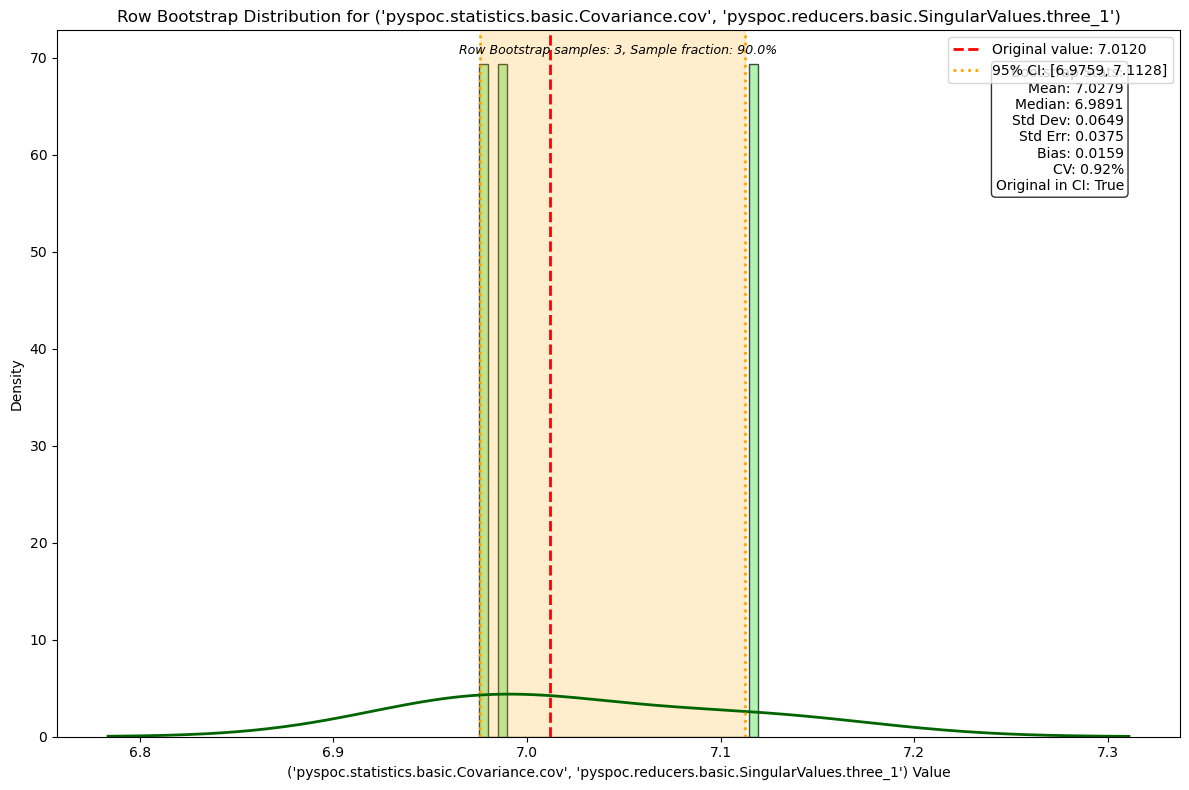

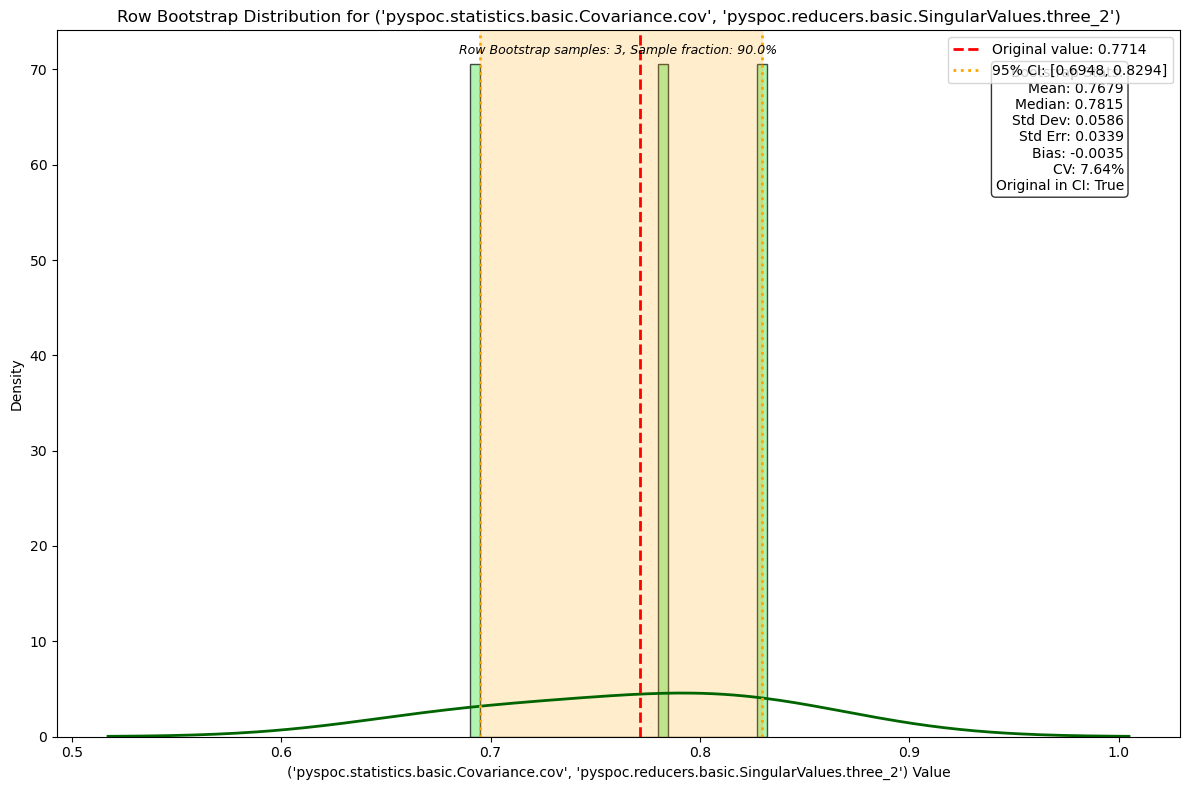

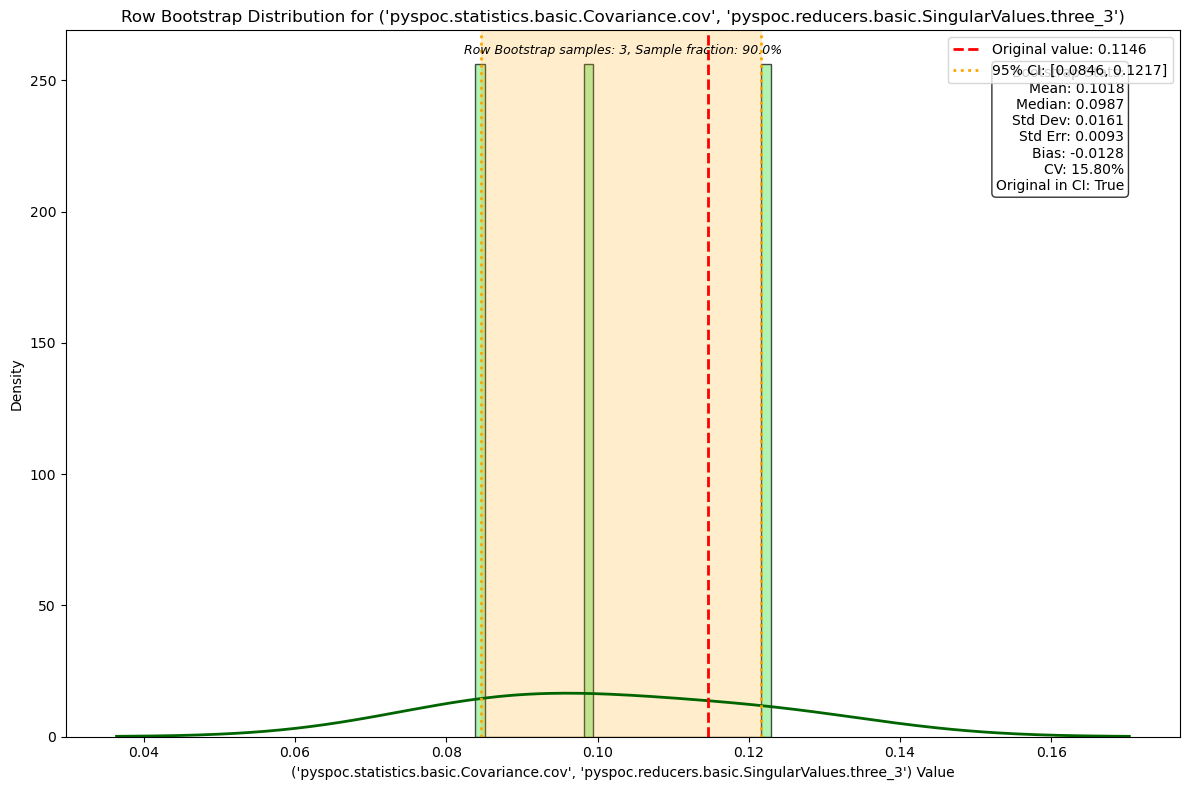

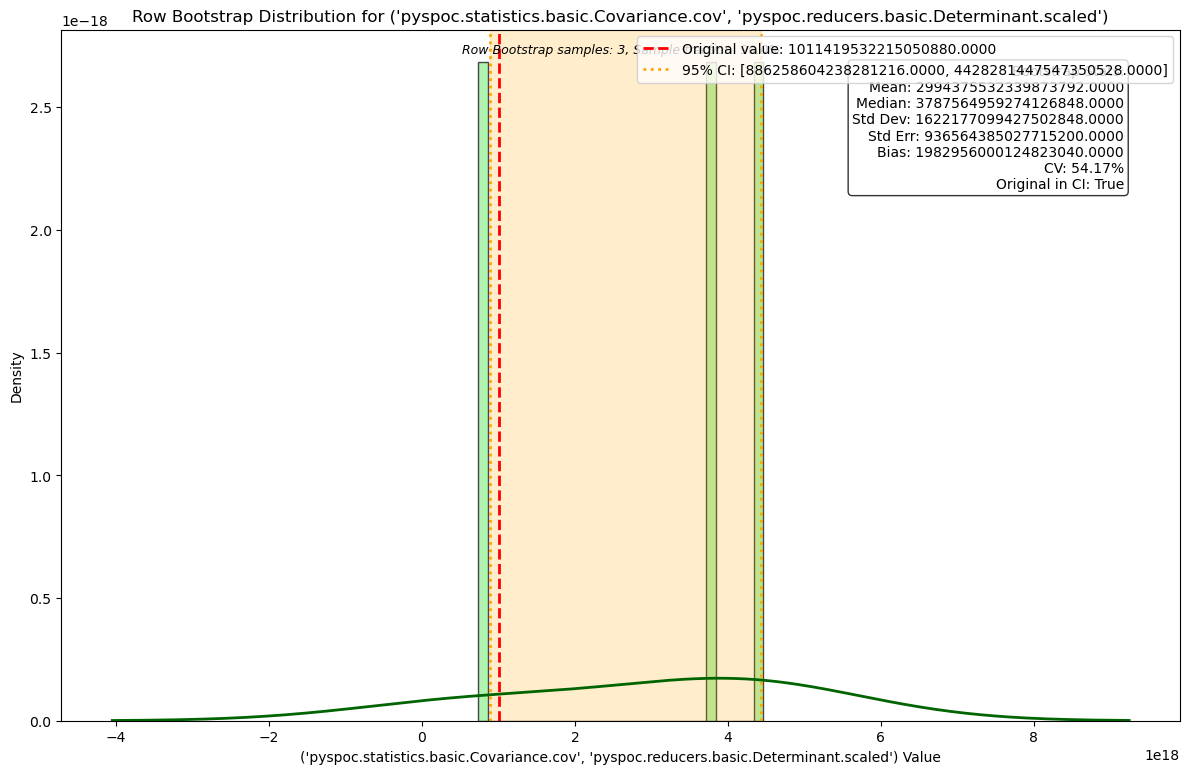

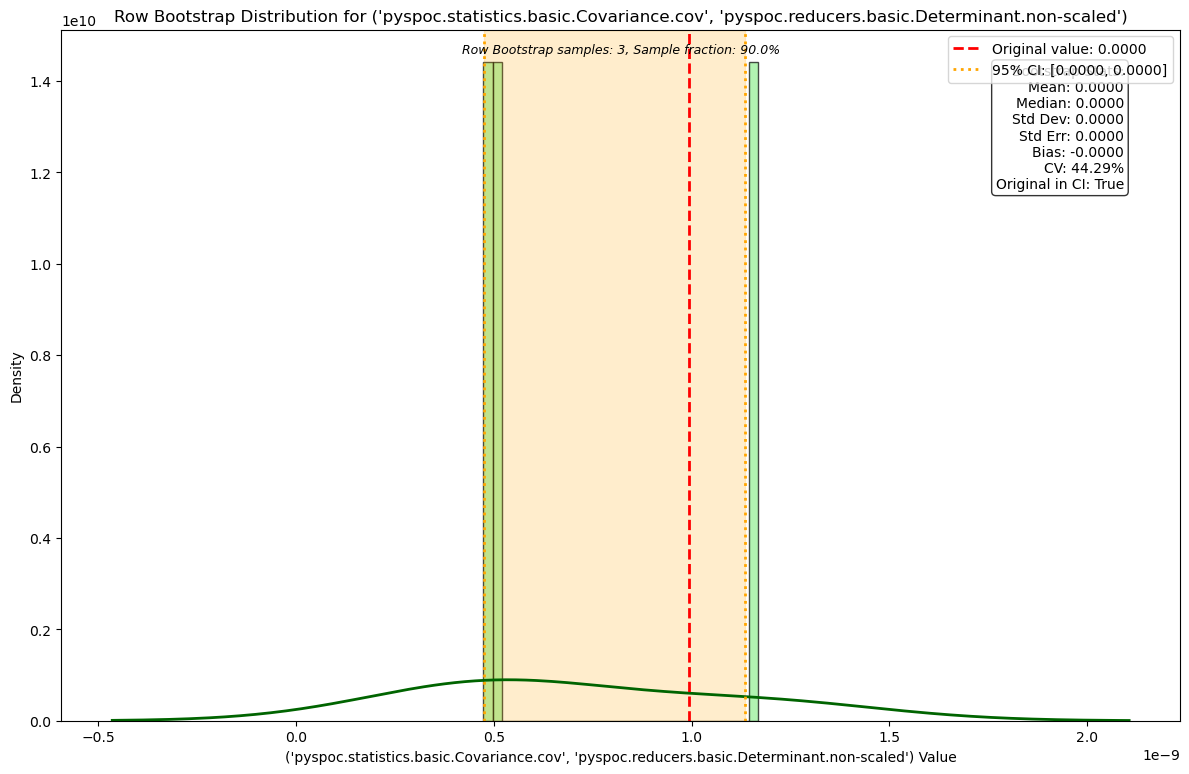

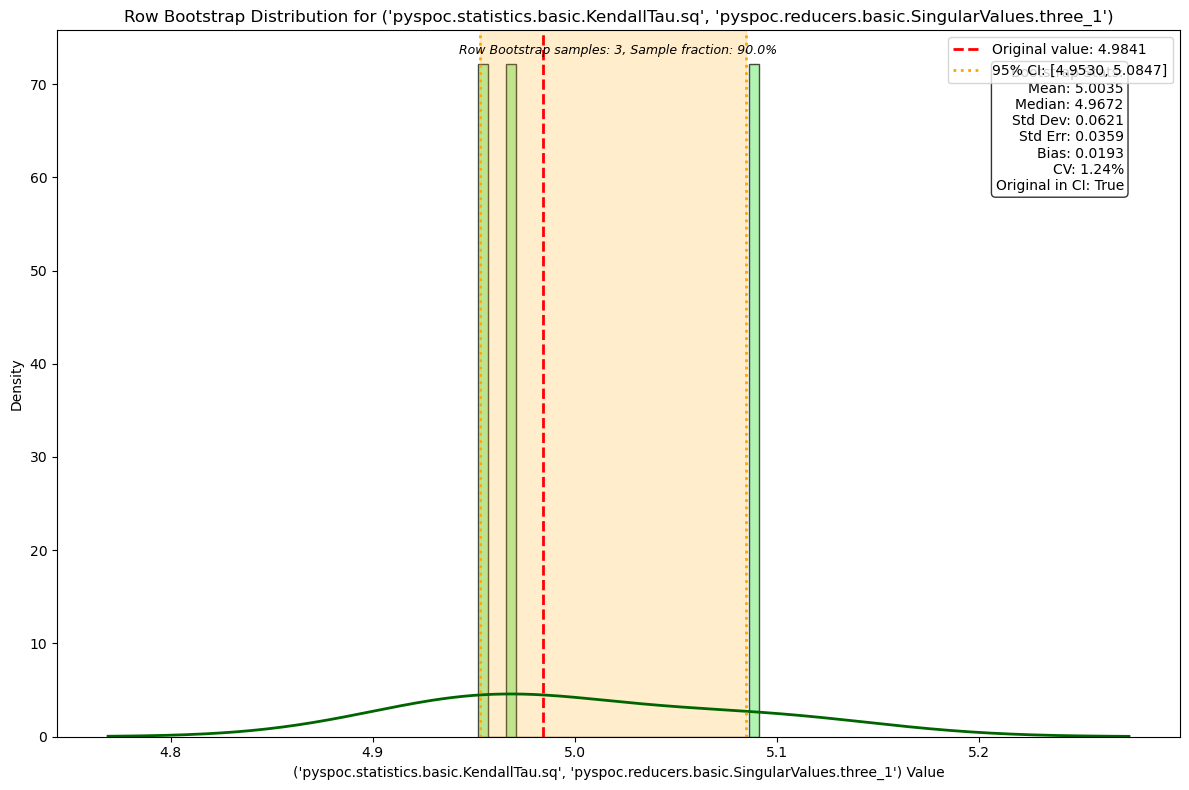

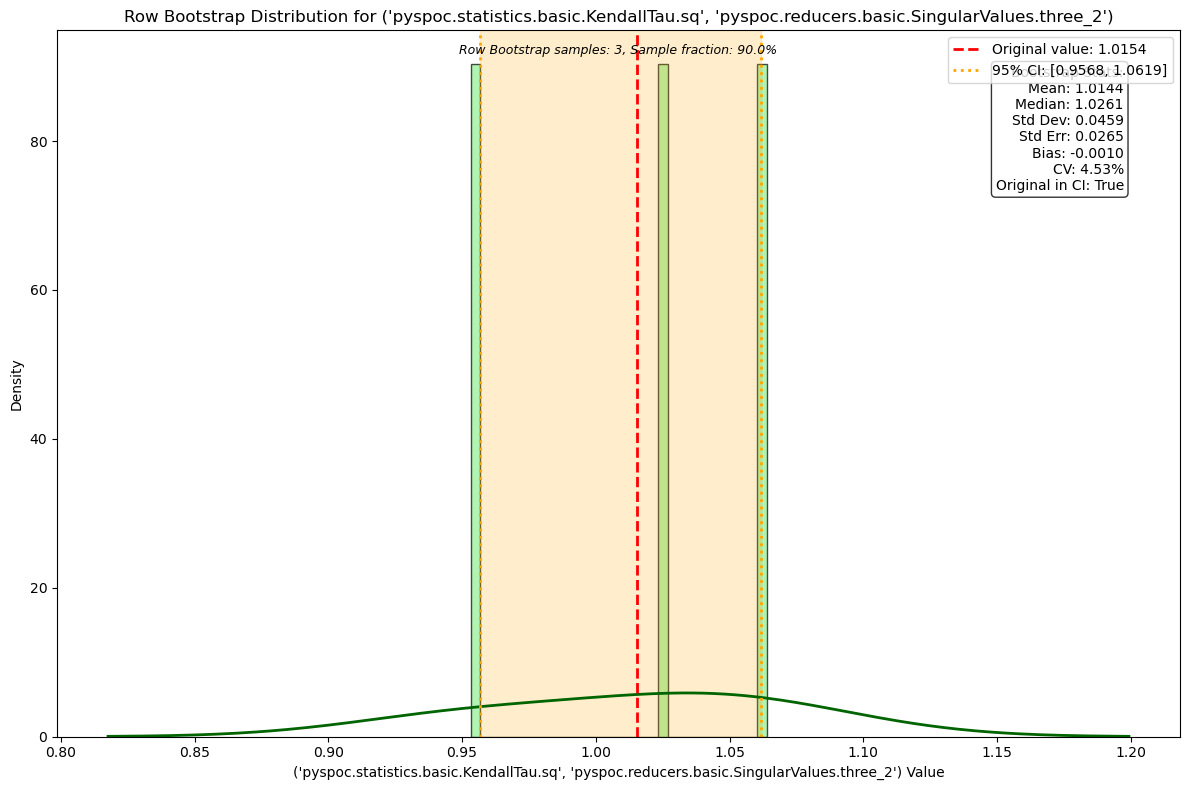

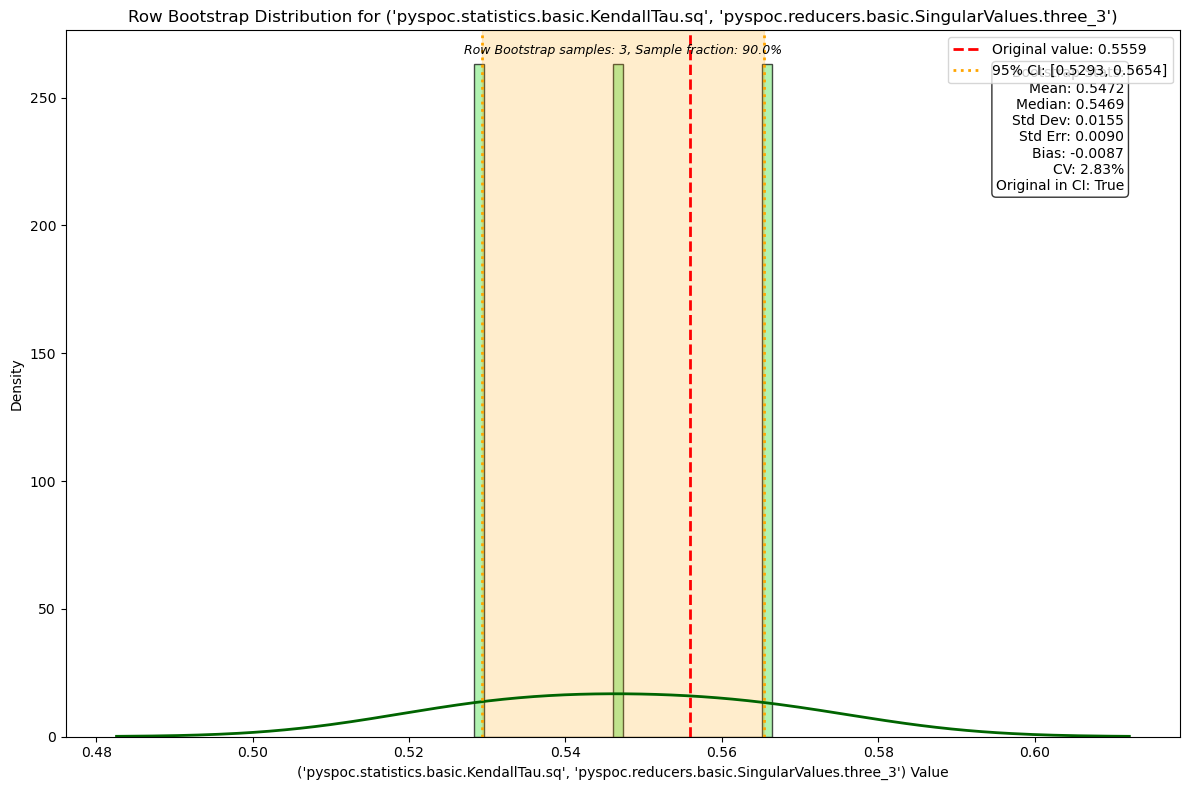

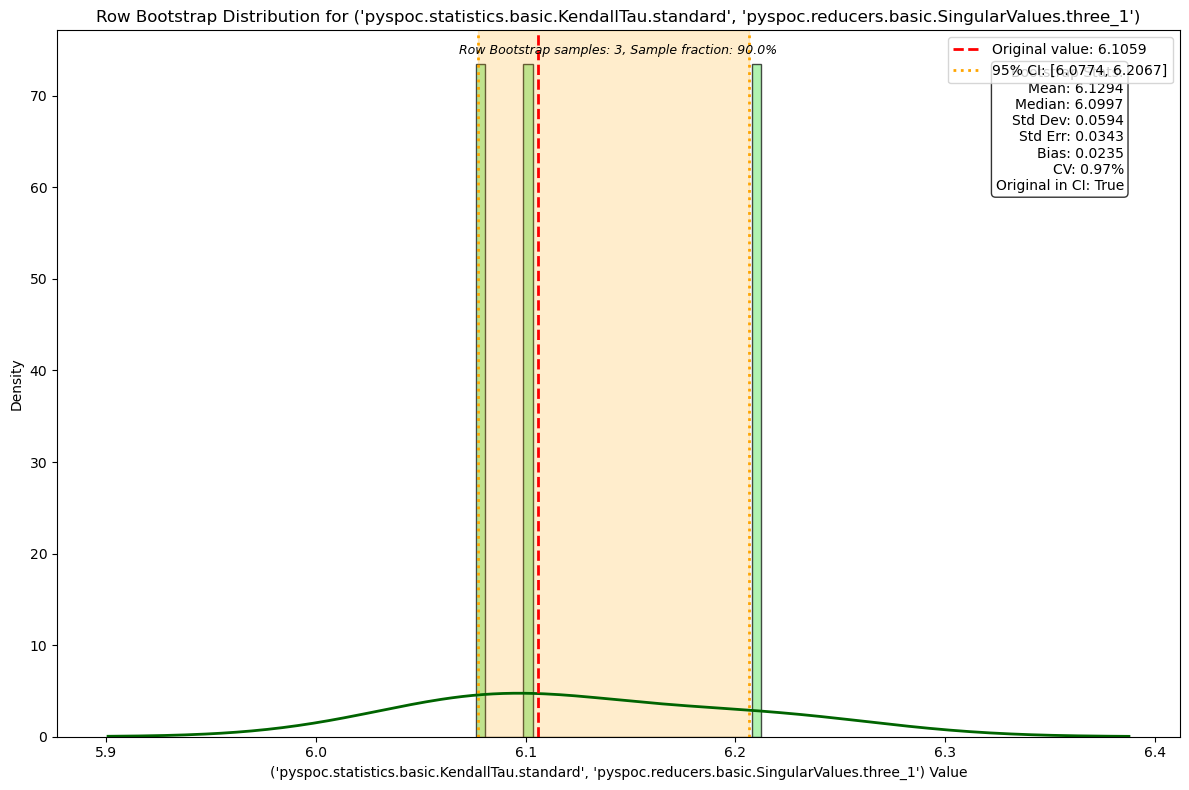

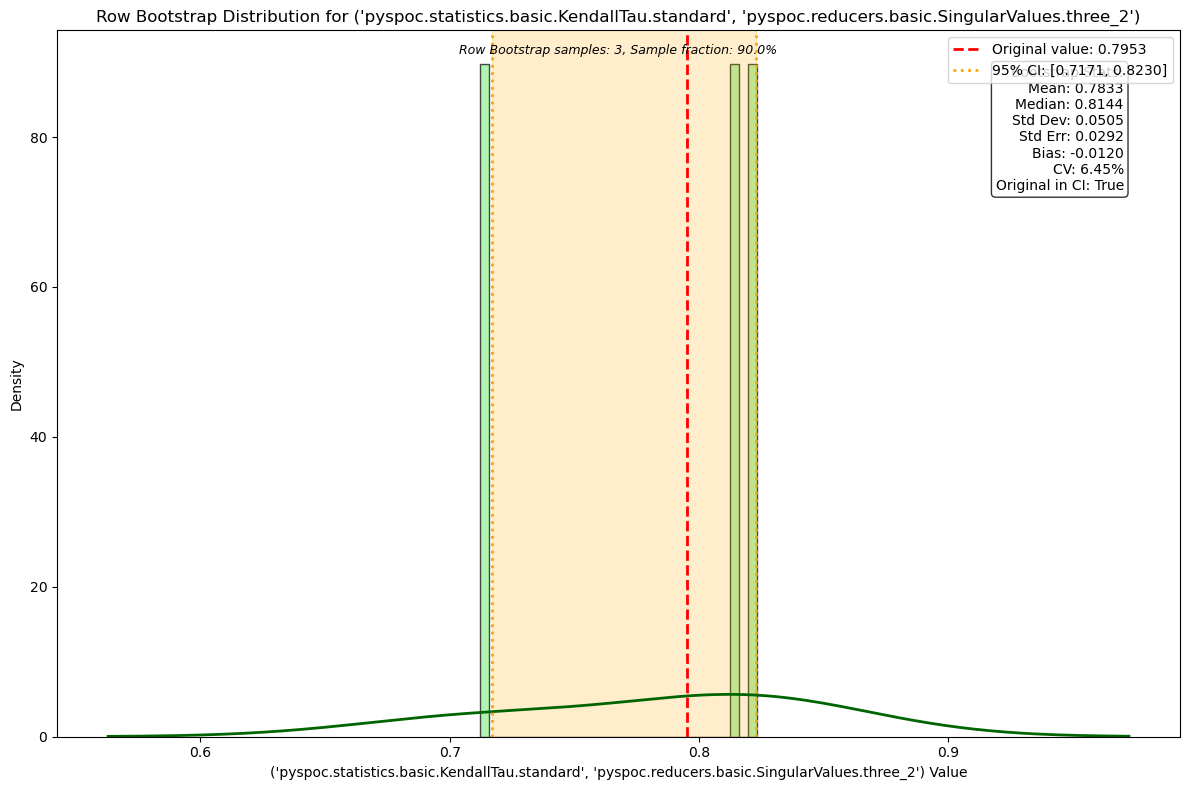

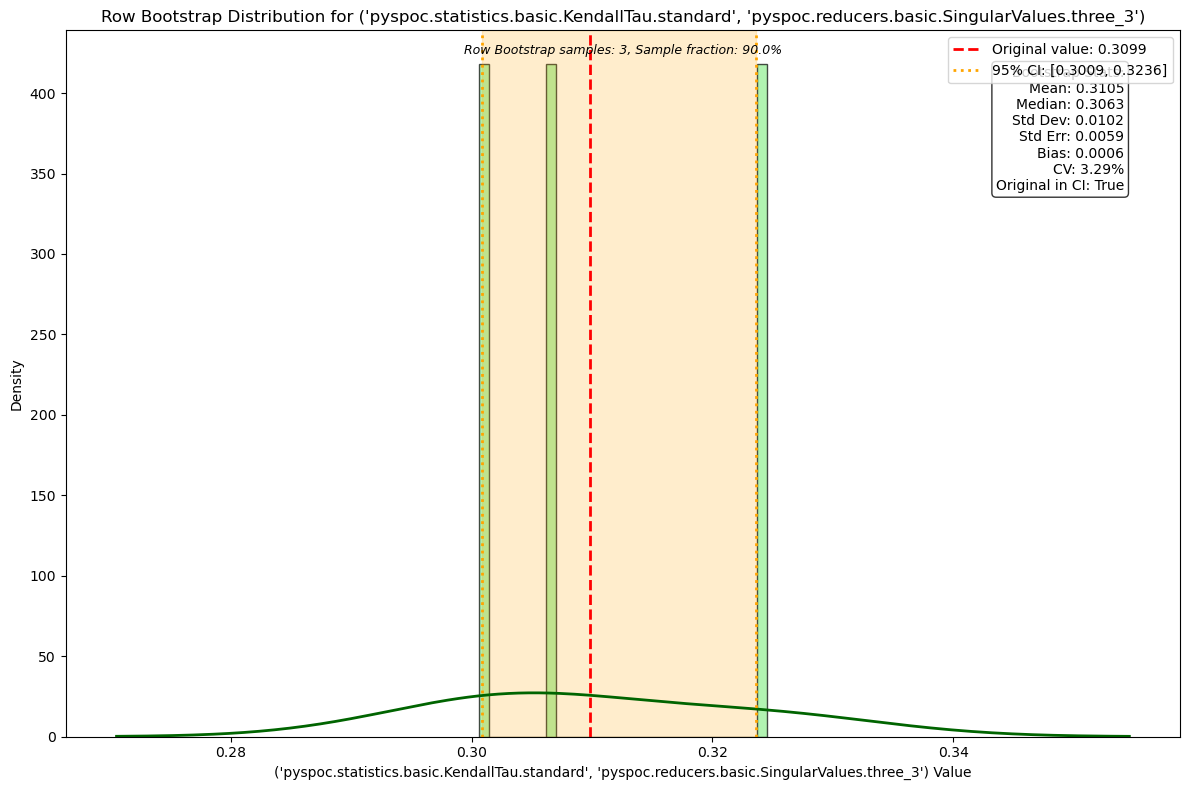

In [30]:
plot_all_bootstrap_distributions(bootstrap_results)

In [31]:
def bootstrap_sample_columns(df: pd.DataFrame, sample_fraction: float = 0.9, random_seed: Optional[int] = None) -> pd.DataFrame:
    """
    Create a bootstrap sample from the dataframe by sampling a fraction of columns without replacement.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    n_samples = max(1, int(len(df.columns) * sample_fraction))
    sampled_columns = np.random.choice(df.columns, size=n_samples, replace=False)
    bootstrap_df = df.loc[:, sampled_columns].copy()
    return bootstrap_df

def pyspi_calc_bootstrap_columns(df: pd.DataFrame,config_name: str, yaml, normalize: Optional[str] = None,
                        sample_fraction: float = 0.9, random_seed: Optional[int] = None):
    """

    Parameters:
    -----------
    df: pd.DataFrame
        The DataFrame containing the data to change
    config_name: str
        Name of the configuration file
    yaml : YAML string for configuration
    normalize : Optional[str], optional
        Method to normalize data (default: None)
    sample_fraction : float, optional
        Fraction of rows to sample for bootstrap (default: 0.9)
    random_seed : Optional[int], optional
        Seed for reproducible sampling (default: None)

    Returns:
    --------
    Dictionary of calculated statistics
    """
    # Load data with optional normalization
    df = load_data(df)

    # Create bootstrap sample
    bootstrap_df = bootstrap_sample_columns(df, sample_fraction=sample_fraction, random_seed=random_seed)
    if normalize is not None:
        bootstrap_df = normalize_data(bootstrap_df, method=normalize)
    # Use Calculator class to compute the statistics
    cfg = Config.from_yaml(config_name, yaml)
    calc = Calculator(bootstrap_df, normalise=False)
    calc.compute(cfg)
    return calc.results


def bootstrap_test_columns(
    df: pd.DataFrame,
    config_name,
    yaml,
    calc,
    n_bootstrap_columns: int = 10,
    sample_fraction_columns: float = 0.9,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    save_bootstrap_data: bool = True,
    orig_calc_table: Optional[Dict] = None,  
) -> Dict[str, Dict[str, Dict[str, Any]]]:
    """
    Perform bootstrap sampling test to assess variability of statistics.
    """
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    # Use provided orig_calc_table or compute if not given
    if orig_calc_table is None:
        orig_calc_table = pyspi_calc(df, config_name,yaml, normalize=normalize)
    
    orig_results = {
        reducer: orig_calc_table[reducer].values[0] for reducer in REDUCERS
    }
    
    # Store bootstrap values for variance calculation and plotting
    bootstrap_values = {reducer: [] for reducer in REDUCERS}

    # Run bootstrap samples with progress bar
    iter_range = tqdm(range(n_bootstrap_columns), desc="Bootstrap sampling")
    for i in iter_range:
        # Use different random seed for each bootstrap sample
        bootstrap_seed = None if random_seed is None else random_seed + i + 1
        # Get bootstrap sample statistics
        bootstrap_calc_table = pyspi_calc_bootstrap_columns(df, config_name,yaml, normalize=normalize,
                                                   sample_fraction=sample_fraction_columns, random_seed=bootstrap_seed)

        for reducer_name in REDUCERS:
            try:
                bootstrap_value = bootstrap_calc_table[reducer_name].values[0]
                bootstrap_values[reducer_name].append(bootstrap_value)
            except:
                continue
            
    # Calculate bootstrap statistics and add to results
    
    final_results = {}
    for reducer_name in REDUCERS:
        orig_value = orig_results[reducer_name]
        result = {
            'original_value': orig_value,
            'n_bootstrap': n_bootstrap_columns,
            'sample_fraction': sample_fraction_columns
        }

        if save_bootstrap_data and bootstrap_values[reducer_name]:
            bootstrap_data = bootstrap_values[reducer_name]

            # Calculate confidence intervals (2.5% and 97.5% percentiles for 95% CI)
            ci_lower = np.percentile(bootstrap_data, 2.5)
            ci_upper = np.percentile(bootstrap_data, 97.5)

            result.update({
                'bootstrap_mean': np.mean(bootstrap_data),
                'bootstrap_median': np.median(bootstrap_data),
                'bootstrap_std': np.std(bootstrap_data),
                'bootstrap_variance': np.var(bootstrap_data),
                'bootstrap_std_err': np.std(bootstrap_data) / np.sqrt(len(bootstrap_data)),
                'bootstrap_min': np.min(bootstrap_data),
                'bootstrap_max': np.max(bootstrap_data),
                'bootstrap_ci_lower': ci_lower,
                'bootstrap_ci_upper': ci_upper,
                'bootstrap_distribution': bootstrap_data if save_bootstrap_data else None,
                'original_in_ci': ci_lower <= orig_value <= ci_upper,
                'bias': np.mean(bootstrap_data) - orig_value,
                'coefficient_of_variation': np.std(bootstrap_data) / np.abs(np.mean(bootstrap_data)) * 100 if np.mean(bootstrap_data) != 0 else np.nan
            })

        final_results[reducer_name] = result

    return final_results

def plot_bootstrap_distribution_columns(results: Dict, reducer,
                               figsize: Tuple[int, int] = (10, 6)) -> Figure:
    """
    Plot the distribution of bootstrap test values for columns

    Parameters:
    -----------
    results : Dict
        Dictionary containing bootstrap test results.
    reducer : str
        Name of the reducer
    figsize : Tuple[int, int], optional
        Figure size (width, height), by default (10, 6)

    Returns:
    --------
    Figure
        Matplotlib figure object.
    """
    # Extract data
    result = results[reducer]
    bootstrap_values = result['bootstrap_distribution']
    orig_value = result['original_value']
    ci_lower = result['bootstrap_ci_lower']
    ci_upper = result['bootstrap_ci_upper']

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot histogram of bootstrap values
    n, bins, patches = ax.hist(bootstrap_values, bins=30, alpha=0.7, color='lightgreen',
                              edgecolor='black', density=True)

    # Add kernel density
    sns.kdeplot(bootstrap_values, color='darkgreen', ax=ax, linewidth=2)

    # Add vertical line for original value
    ax.axvline(x=orig_value, color='red', linestyle='--', linewidth=2,
              label=f'Original value: {orig_value:.4f}')

    # Add confidence interval lines
    ax.axvline(x=ci_lower, color='orange', linestyle=':', linewidth=2,
              label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
    ax.axvline(x=ci_upper, color='orange', linestyle=':', linewidth=2)

    # Fill confidence interval area
    ax.axvspan(ci_lower, ci_upper, alpha=0.2, color='orange')

    # Add bootstrap statistics
    stats_text = (
        f"Bootstrap Stats:\n"
        f"Mean: {result['bootstrap_mean']:.4f}\n"
        f"Median: {result['bootstrap_median']:.4f}\n"
        f"Std Dev: {result['bootstrap_std']:.4f}\n"
        f"Bias: {result['bias']:.4f}\n"
        f"Std Err: {result['bootstrap_std_err']:.4f}\n"
        f"CV: {result['coefficient_of_variation']:.2f}%\n"
        f"Original in CI: {result['original_in_ci']}"
    )

    # Add the stats text as an annotation
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add labels and title
    ax.set_xlabel(f'{reducer} Value')
    ax.set_ylabel('Density')
    ax.set_title(f'Column Bootstrap Distribution for {reducer}')

    # Add subtitle with sample info
    subtitle = f'Column Bootstrap samples: {result["n_bootstrap"]}, Sample fraction: {result["sample_fraction"]:.1%}'
    ax.text(0.5, 0.98, subtitle, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', horizontalalignment='center', style='italic')

    ax.legend()
    fig.tight_layout()

    return fig


def plot_all_bootstrap_distributions_columns(results: Dict, figsize: Tuple[int, int] = (12, 8)) -> Dict[str, Figure]:
    figures = {}
    for reducer_name, reducer_results in results.items():
        key = str(reducer_name)
        try:
            fig = plot_bootstrap_distribution_columns(results, reducer_name, figsize=figsize)
            figures[key] = fig
        except Exception as e:
            print(f"Error plotting bootstrap {reducer_name}: {e}")
    return figures

In [32]:
def perturbation_test(
    df: pd.DataFrame,
    config_name,
    yaml,
    calc,
    n_perturbations: int = 1000,
    scale_factor: float = 0.1,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    save_perturbation_data: bool = True,
    orig_calc_table: Optional[Dict] = None,
) -> Dict[str, Dict[str, Any]]:
    """
    Perform a perturbation test to assess statistical significance and calculate variance.
    """
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    # Use provided orig_calc_table or compute
    if orig_calc_table is None:
        orig_calc_table = pyspi_calc(df, config_name, yaml, normalize=normalize)

    orig_results = {
        reducer: orig_calc_table[reducer].values[0] for reducer in REDUCERS
    }
    
    perturb_values = {reducer: [] for reducer in REDUCERS}

    # Run perturbations with progress bar
    iter_range = tqdm(range(n_perturbations), desc="Perturbation sampling")
    for i in iter_range:
        # Use different random seed for each perm
        perturb_seed = None if random_seed is None else random_seed + i + 1
        # Get shuffled data statistics
        perturb_calc_table = pyspi_calc(df, config_name,yaml, normalize=normalize, perturb=True, scale_factor=scale_factor,random_seed=perturb_seed)

        for reducer in REDUCERS:
            perturb_value = perturb_calc_table[reducer].values[0]
            # Append the value to the list
            perturb_values[reducer].append(perturb_value)

    # Calculate p-values, variances, and add to results
    # Create the DataFrame of perturbation results 
    # The index length should match the number of perturbations
    perturb_data = pd.DataFrame(perturb_values)
    # Calculate p-values, variances, and add to results
    final_results = {}
    for reducer in REDUCERS:
        # Access the specific reducer's data from the perm_data DataFrame
        perturb_data_series = perturb_data[reducer]
        orig_value = orig_results[reducer]
        n = len(perturb_data_series) # Use the length of the collected data

        # Calculate permutation percentile for p-value
        lower_tail = np.sum(perturb_data_series < orig_value) / n
        upper_tail = np.sum(perturb_data_series > orig_value) / n
        perturbation_percentile = min(lower_tail, upper_tail)
        p_value = perturbation_percentile * 2 # Multiply by 2 for a two-tailed test

        result = {'value': orig_value,
              'p_value': p_value}

        # Update results with permutation statistics
        result.update({
            'perturbation_mean': np.mean(perturb_data_series),
            'perturbation_median': np.median(perturb_data_series),
            'perturbation_std': np.std(perturb_data_series),
            'perturbation_variance': np.var(perturb_data_series),
            'perturbation_std_err': np.std(perturb_data_series) / np.sqrt(n),
            'perturbation_min': np.min(perturb_data_series),
            'perturbation_max': np.max(perturb_data_series),
            'perturbation_distribution': perturb_data_series.tolist() if save_perturbation_data else None, # Store as list if needed
            'perturbation_percentile_rank': perturbation_percentile
        })

        final_results[reducer] = result
    return final_results


def plot_perturbation_distribution(results: Dict, reducer: str,
                                 figsize: Tuple[int, int] = (10, 6)) -> Figure:
    """
    Plot the distribution of perturbation test values

    Parameters:
    -----------
    results : Dict
        Dictionary containing perturbation test results.
    reducer : str
        Name of the reducer
    figsize : Tuple[int, int], optional
        Figure size (width, height), by default (10, 6)

    Returns:
    --------
    Figure
        Matplotlib figure object.
    """

    # Extract data
    result = results[reducer]
    perturb_values = result['perturbation_distribution']
    orig_value = result['value']
    p_value = result['p_value']

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot histogram of permutation values
    n, bins, patches = ax.hist(perturb_values, bins=30, alpha=0.7, color='skyblue',
                              edgecolor='black', density=True)

    # Add kernel density estimate
    sns.kdeplot(perturb_values, color='navy', ax=ax, linewidth=2)

    # Add vertical line for original value
    ax.axvline(x=orig_value, color='red', linestyle='--', linewidth=2,
              label=f'Original value: {orig_value:.4f}')

    # Add permutation statistics
    stats_text = (
        f"Perturbation Stats:\n"
        f"Mean: {result['perturbation_mean']:.4f}\n"
        f"Median: {result['perturbation_median']:.4f}\n"
        f"Std Dev: {result['perturbation_std']:.4f}\n"
        f"Std Err: {result['perturbation_std_err']:.4f}\n"
        f"p-value: {p_value:.4f}"
    )

    # Add the stats text as an annotation
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add labels and title
    ax.set_xlabel(f'{reducer} Value')
    ax.set_ylabel('Density')
    ax.set_title(f'Perturbation Distribution for {reducer}')

    ax.legend()
    fig.tight_layout()

    return fig


def plot_all_perturbation_distributions(results: Dict, figsize: Tuple[int, int] = (12, 8)) -> Dict[str, Figure]:
    figures = {}
    for reducer_name, reducer_results in results.items():
        # Convert reducer_name to string for safe dict key
        key = str(reducer_name)
        if (isinstance(reducer_results, dict) and
            'perturbation_distribution' in reducer_results and
            'value' in reducer_results):
            try:
                fig = plot_perturbation_distribution(results, reducer_name, figsize=figsize)
                figures[key] = fig
            except Exception as e:
                print(f"Error plotting {reducer_name}: {e}")
    return figures


In [33]:
def perturbation_test(
    df: pd.DataFrame,
    config_name,
    yaml,
    calc,
    n_perturbations: int = 1000,
    scale_factor: float = 0.1,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    save_perturbation_data: bool = True,
    orig_calc_table: Optional[Dict] = None,
) -> Dict[str, Dict[str, Any]]:
    """
    Perform a perturbation test to assess statistical significance and calculate variance.
    """
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    # Use provided orig_calc_table or compute
    if orig_calc_table is None:
        orig_calc_table = pyspi_calc(df, config_name, yaml, normalize=normalize)

    orig_results = {
        reducer: orig_calc_table[reducer].values[0] for reducer in REDUCERS
    }
    
    perturb_values = {reducer: [] for reducer in REDUCERS}

    # Run perturbations with progress bar
    iter_range = tqdm(range(n_perturbations), desc="Perturbation sampling")
    for i in iter_range:
        # Use different random seed for each perm
        perturb_seed = None if random_seed is None else random_seed + i + 1
        # Get shuffled data statistics
        perturb_calc_table = pyspi_calc(df, config_name,yaml, normalize=normalize, perturb=True, scale_factor=scale_factor,random_seed=perturb_seed)

        for reducer in REDUCERS:
            perturb_value = perturb_calc_table[reducer].values[0]
            # Append the value to the list
            perturb_values[reducer].append(perturb_value)

    # Calculate p-values, variances, and add to results
    # Create the DataFrame of perturbation results AFTER collecting all values
    # The index length should match the number of perturbations
    perturb_data = pd.DataFrame(perturb_values)
    # Calculate p-values, variances, and add to results
    final_results = {}
    for reducer in REDUCERS:
        # Access the specific reducer's data from the perm_data DataFrame
        perturb_data_series = perturb_data[reducer]
        orig_value = orig_results[reducer]
        n = len(perturb_data_series) # Use the length of the collected data

        # Calculate permutation percentile for p-value
        lower_tail = np.sum(perturb_data_series < orig_value) / n
        upper_tail = np.sum(perturb_data_series > orig_value) / n
        perturbation_percentile = min(lower_tail, upper_tail)
        p_value = perturbation_percentile * 2 # Multiply by 2 for a two-tailed test

        # Calculate 95% confidence interval (2.5th and 97.5th percentiles)
        ci_lower = np.percentile(perturb_data_series, 2.5)
        ci_upper = np.percentile(perturb_data_series, 97.5)

        result = {'value': orig_value,
              'p_value': p_value}

        # Update results with permutation statistics and CI
        result.update({
            'perturbation_mean': np.mean(perturb_data_series),
            'perturbation_median': np.median(perturb_data_series),
            'perturbation_std': np.std(perturb_data_series),
            'perturbation_variance': np.var(perturb_data_series),
            'perturbation_std_err': np.std(perturb_data_series) / np.sqrt(n),
            'perturbation_min': np.min(perturb_data_series),
            'perturbation_max': np.max(perturb_data_series),
            'perturbation_distribution': perturb_data_series.tolist() if save_perturbation_data else None, # Store as list if needed
            'perturbation_percentile_rank': perturbation_percentile,
            'perturbation_ci_lower': ci_lower,
            'perturbation_ci_upper': ci_upper,
            'original_in_ci': ci_lower <= orig_value <= ci_upper
        })

        final_results[reducer] = result
    return final_results


def plot_perturbation_distribution(results: Dict, reducer: str,
                                 figsize: Tuple[int, int] = (10, 6)) -> Figure:
    """
    Plot the distribution of perturbation test values, including a 95% confidence interval.
    """
    # Extract data
    result = results[reducer]
    perturb_values = result['perturbation_distribution']
    orig_value = result['value']
    p_value = result['p_value']
    ci_lower = result.get('perturbation_ci_lower', None)
    ci_upper = result.get('perturbation_ci_upper', None)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot histogram of permutation values
    n, bins, patches = ax.hist(perturb_values, bins=30, alpha=0.7, color='skyblue',
                              edgecolor='black', density=True)

    # Add kernel density estimate
    sns.kdeplot(perturb_values, color='navy', ax=ax, linewidth=2)

    # Add vertical line for original value
    ax.axvline(x=orig_value, color='red', linestyle='--', linewidth=2,
              label=f'Original value: {orig_value:.4f}')

    # Add confidence interval lines if available
    if ci_lower is not None and ci_upper is not None:
        ax.axvline(x=ci_lower, color='orange', linestyle=':', linewidth=2,
                  label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
        ax.axvline(x=ci_upper, color='orange', linestyle=':', linewidth=2)
        ax.axvspan(ci_lower, ci_upper, alpha=0.2, color='orange')

    # Add permutation statistics
    stats_text = (
        f"Perturbation Stats:\n"
        f"Mean: {result['perturbation_mean']:.4f}\n"
        f"Median: {result['perturbation_median']:.4f}\n"
        f"Std Dev: {result['perturbation_std']:.4f}\n"
        f"Std Err: {result['perturbation_std_err']:.4f}\n"
        f"p-value: {p_value:.4f}\n"
        f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]\n"
        f"Original in CI: {result.get('original_in_ci', False)}"
    )

    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add labels and title
    ax.set_xlabel(f'{reducer} Value')
    ax.set_ylabel('Density')
    ax.set_title(f'Perturbation Distribution for {reducer}')

    ax.legend()
    fig.tight_layout()

    return fig


def plot_all_perturbation_distributions(results: Dict, figsize: Tuple[int, int] = (12, 8)) -> Dict[str, Figure]:
    figures = {}
    for reducer_name, reducer_results in results.items():
        # Convert reducer_name to string for safe dict key
        key = str(reducer_name)
        if (isinstance(reducer_results, dict) and
            'perturbation_distribution' in reducer_results and
            'value' in reducer_results):
            try:
                fig = plot_perturbation_distribution(results, reducer_name, figsize=figsize)
                figures[key] = fig
            except Exception as e:
                print(f"Error plotting {reducer_name}: {e}")
    return figures

#

Perturbation sampling:   0%|          | 0/5 [00:00<?, ?it/s]

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 13.51it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 188.48it/s]



Calculation complete. Time taken: 0.2400s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 20.95it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 217.17it/s]


...

Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 24.91it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 143.27it/s]



Calculation complete. Time taken: 0.1474s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 21.24it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 226.82it/s]



Calculation complete. Time taken: 0.1578s


{"('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_1')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_2')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_3')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.Determinant.scaled')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.Determinant.non-scaled')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.KendallTau.sq', 'pyspoc.reducers.basic.SingularValues.three_1')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.KendallTau.sq', 'pyspoc.reducers.basic.SingularValues.three_2')": <Figure size 1200x800 with 1 Axes>,
 "('pyspoc.statistics.basic.KendallTau.sq', 'pyspoc.reducers.basic.SingularValues.three_3

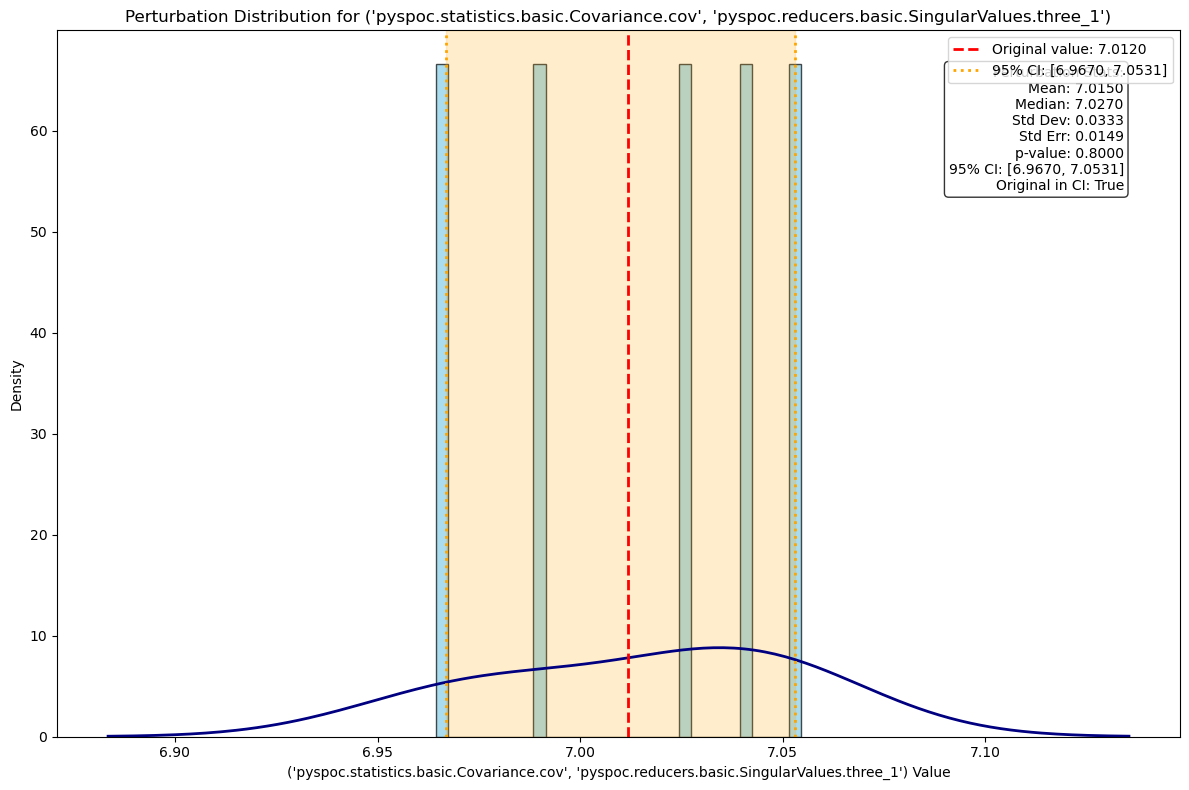

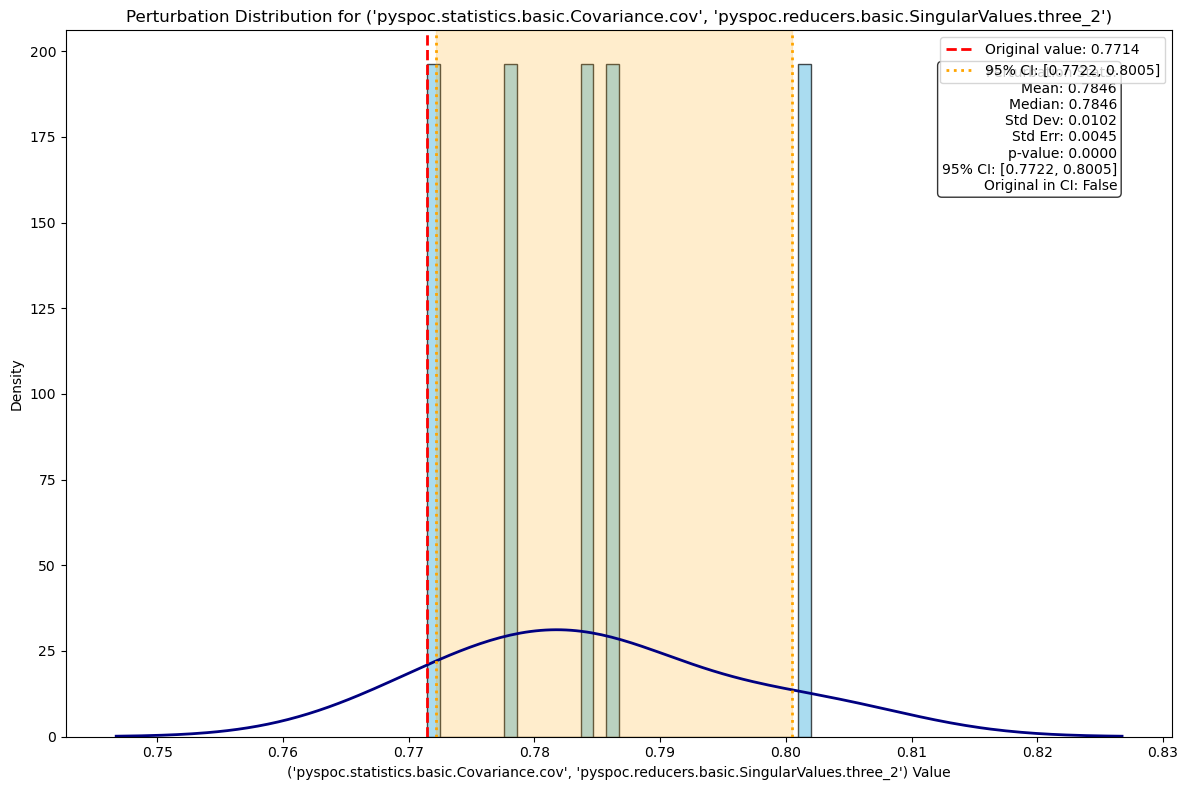

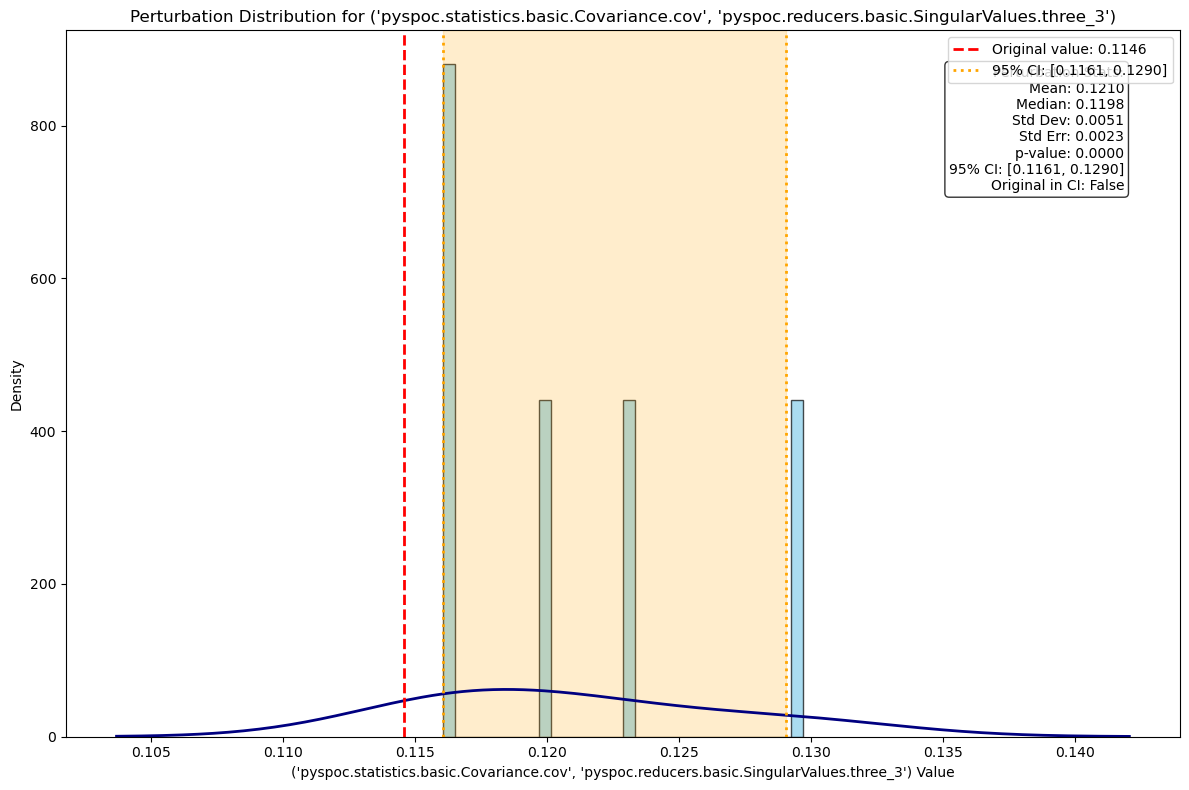

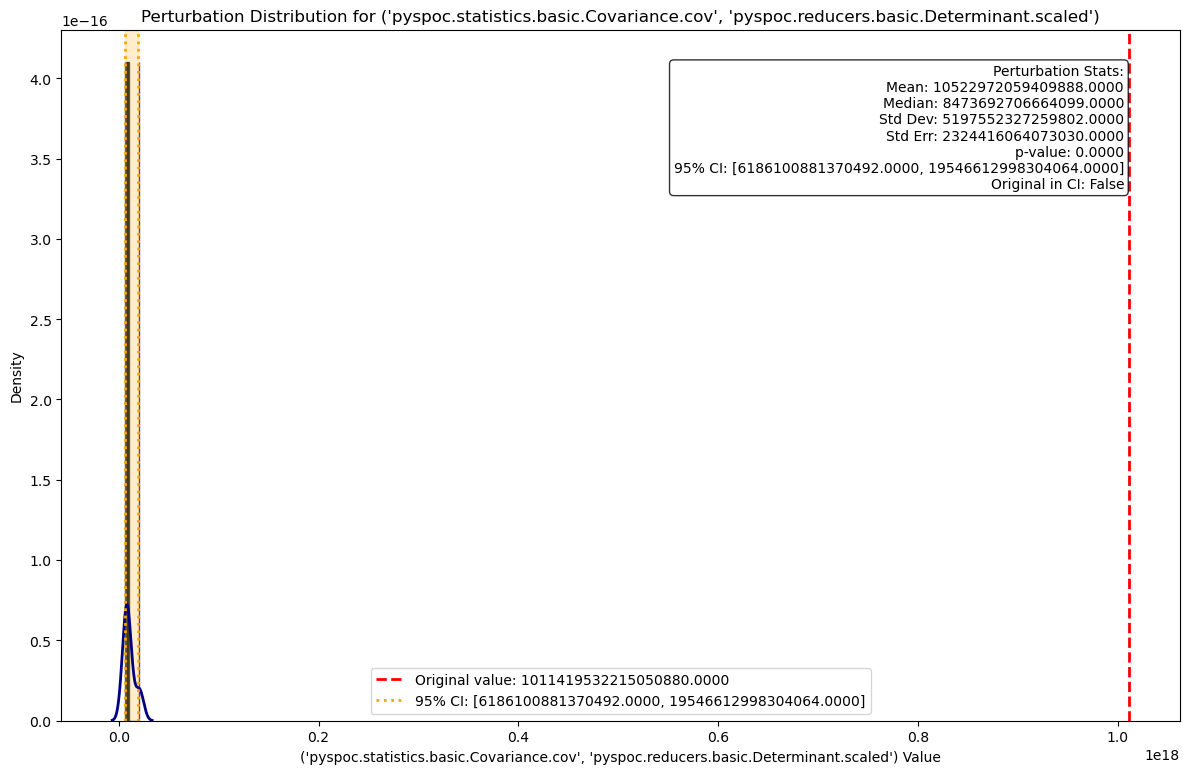

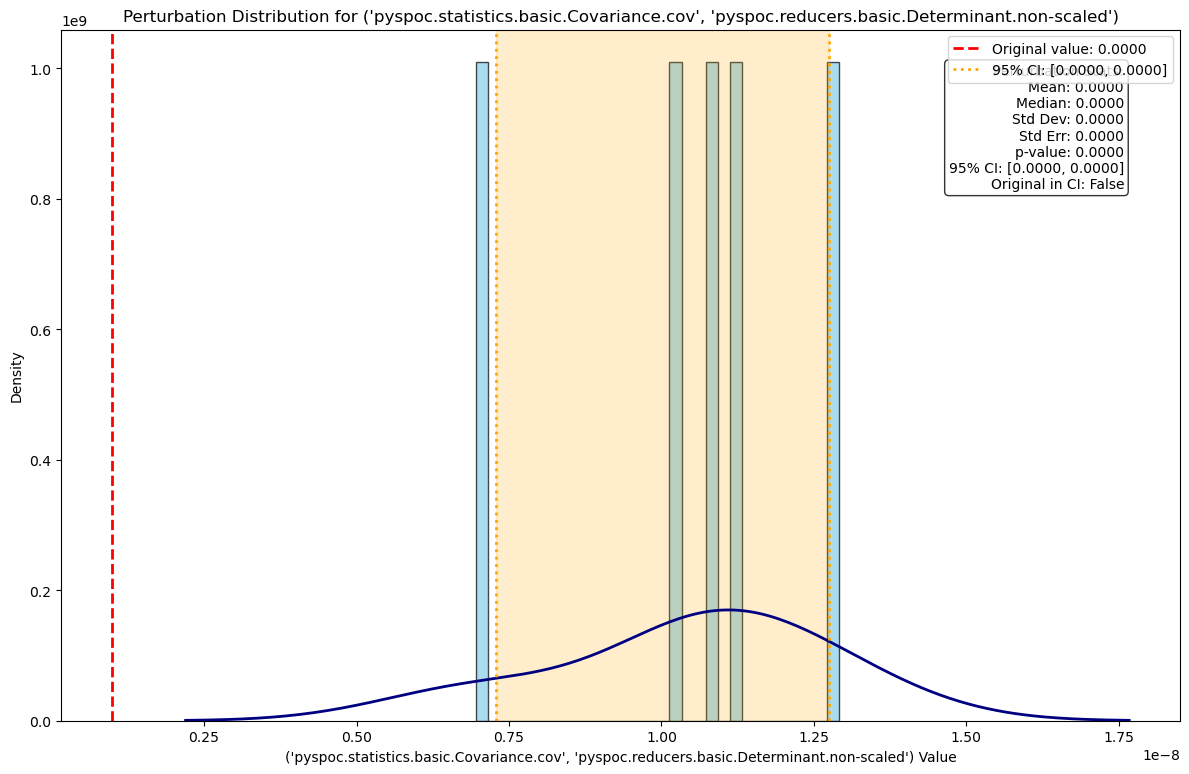

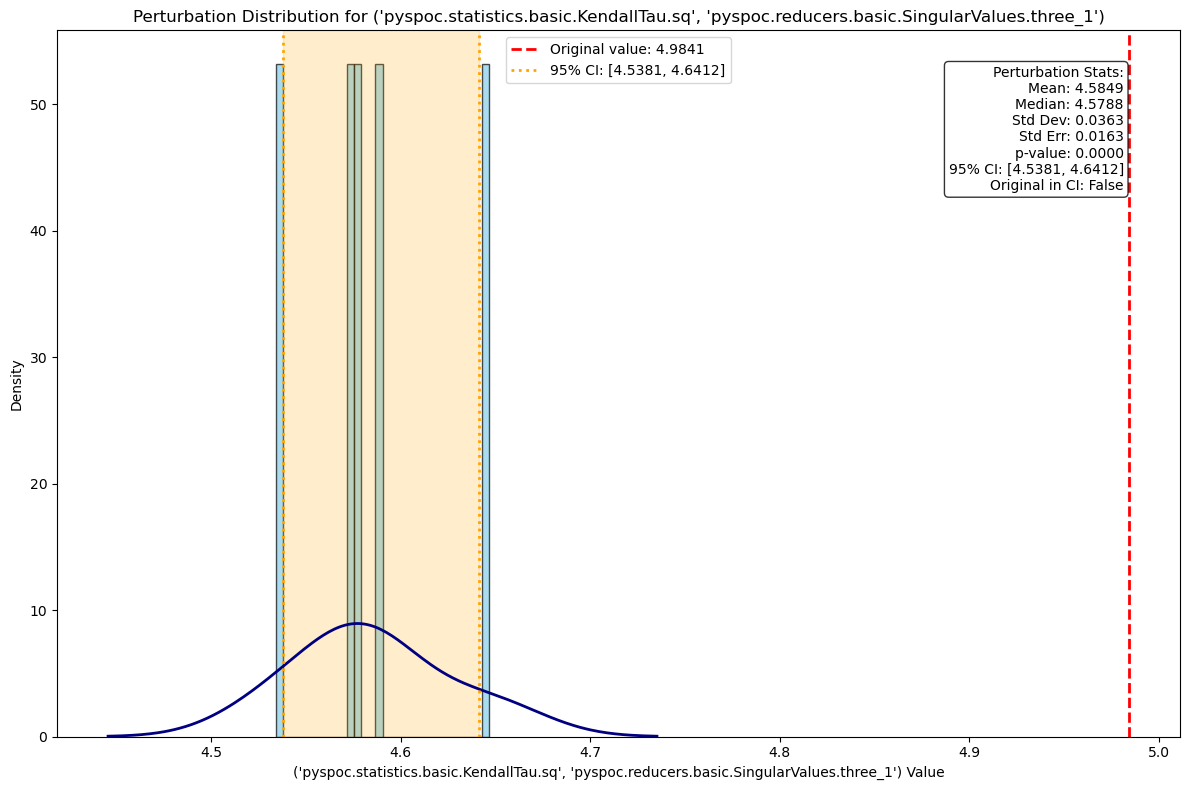

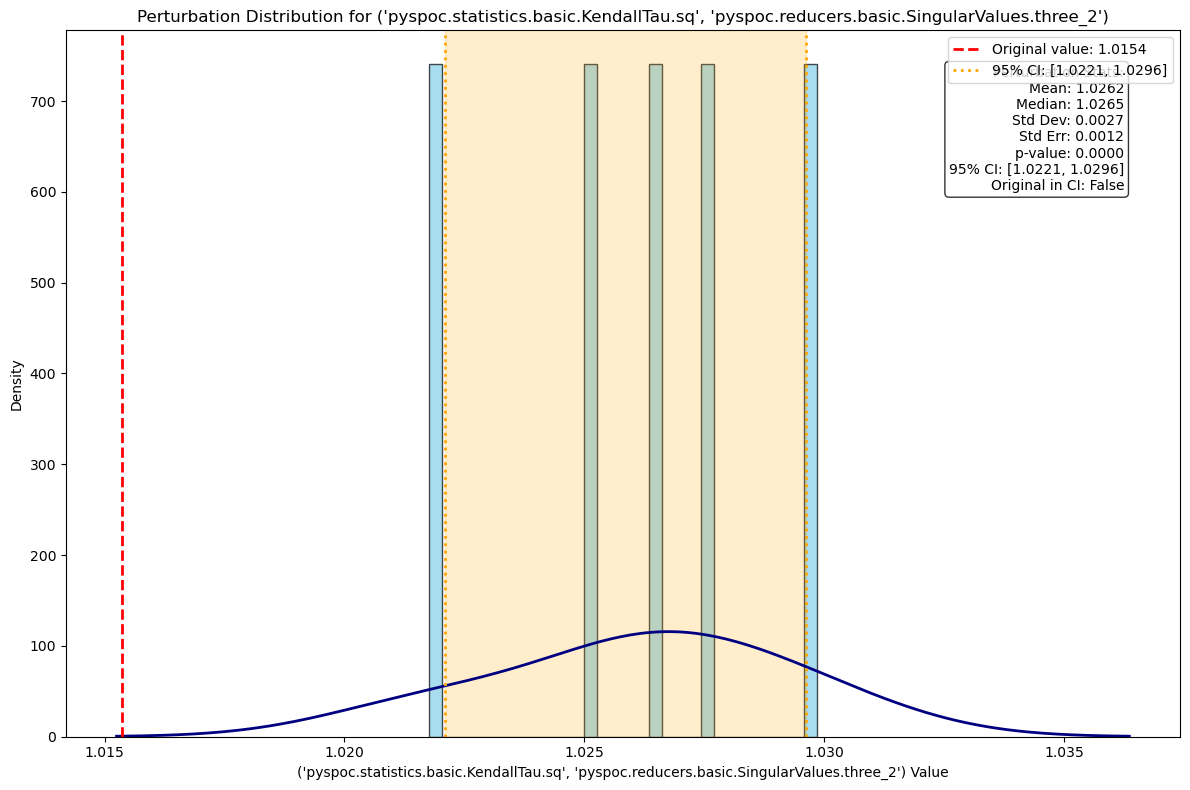

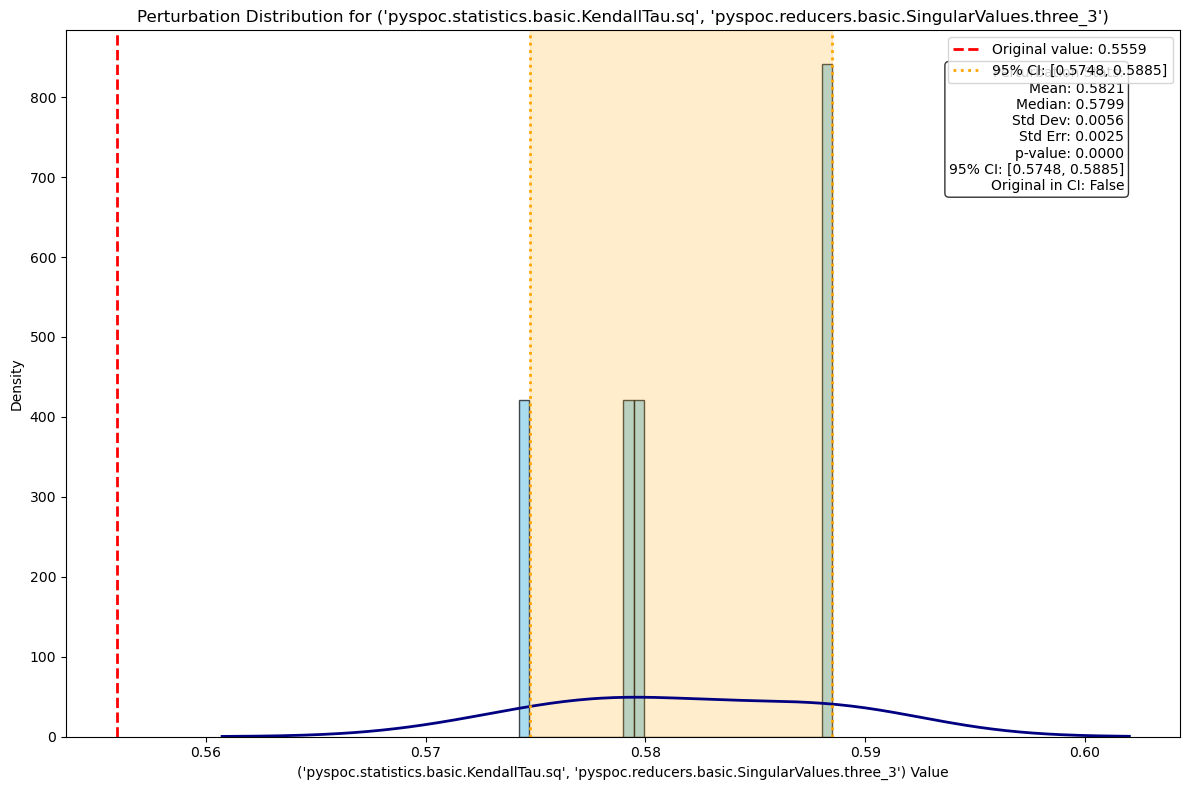

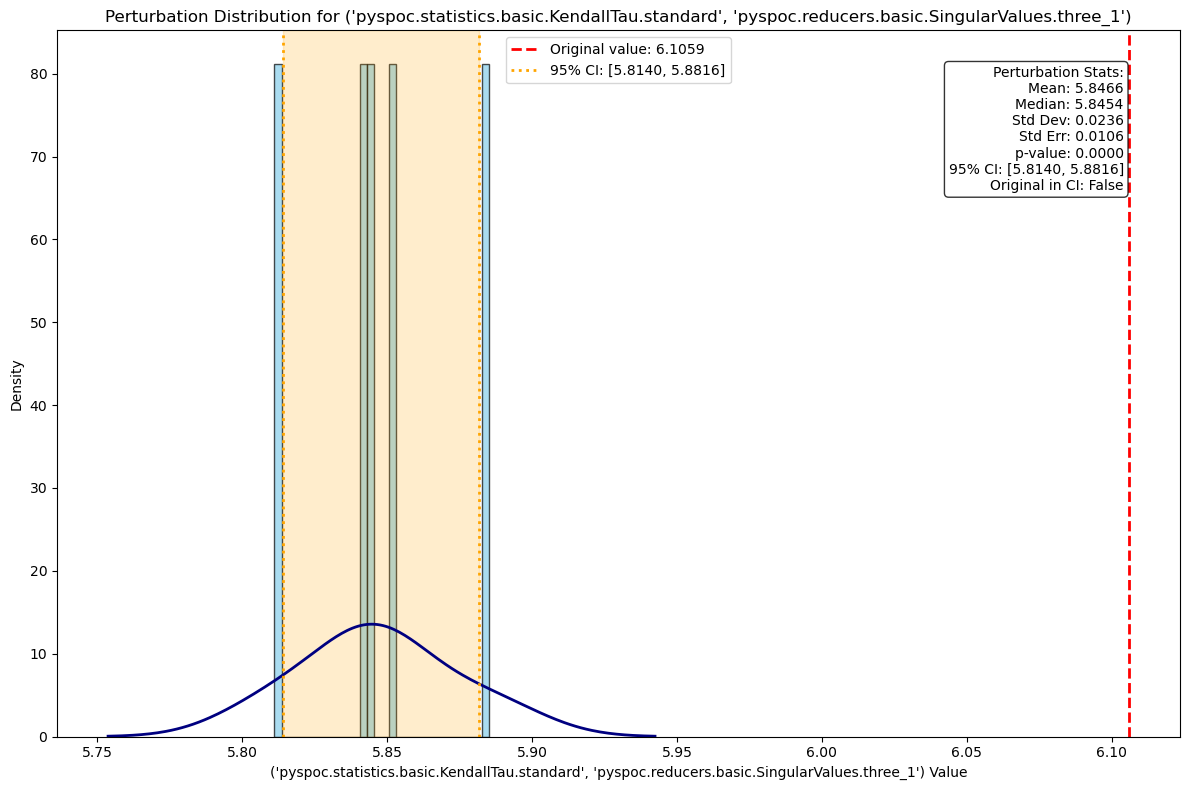

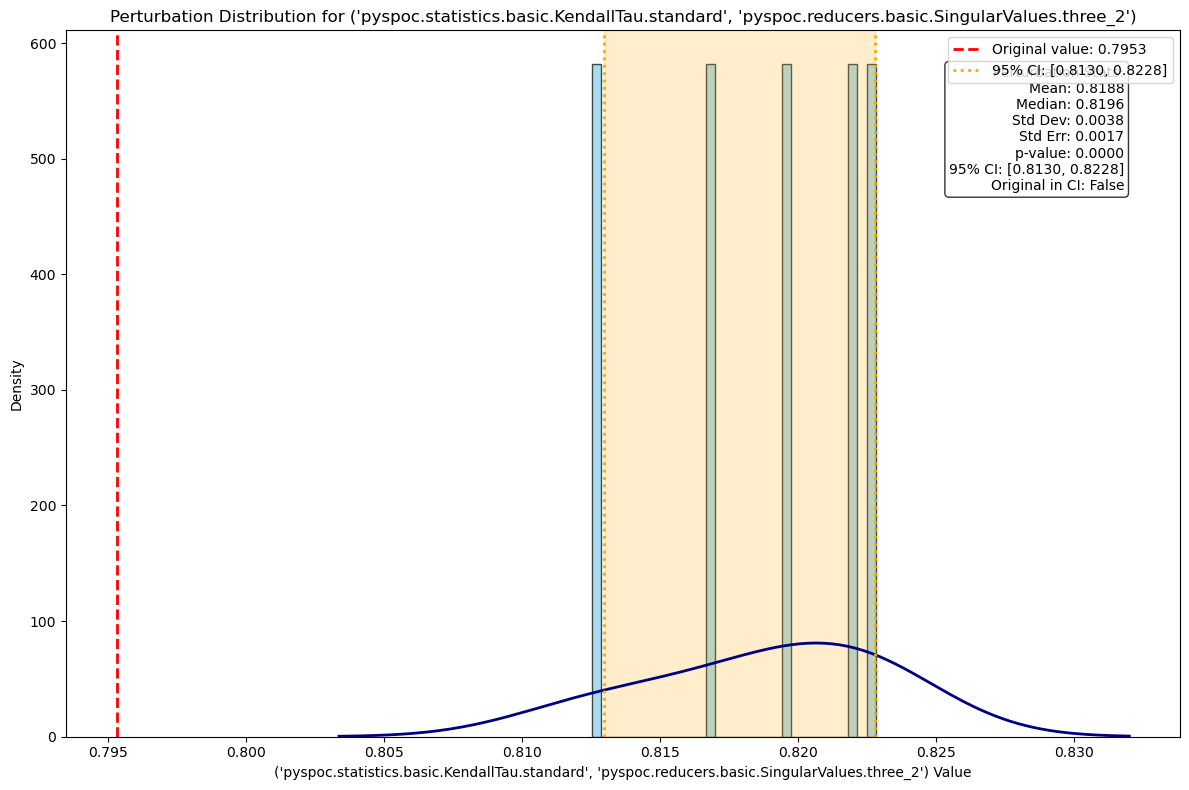

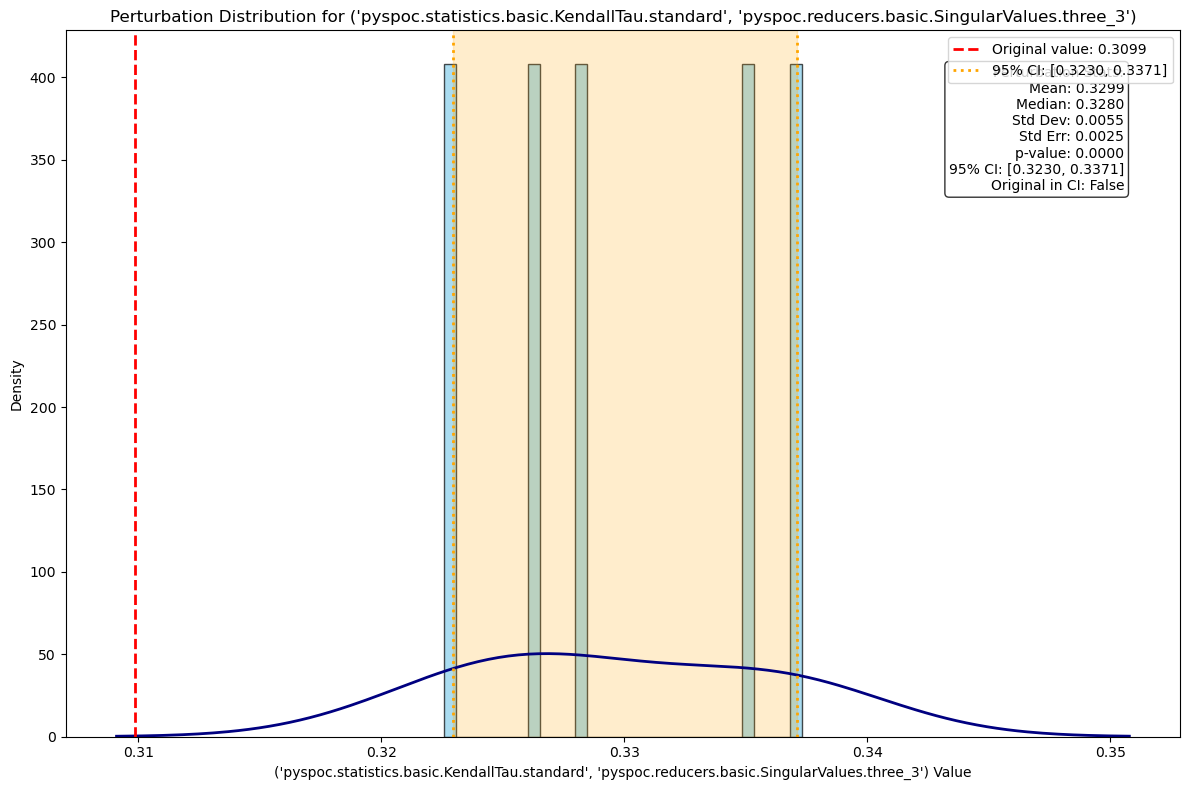

In [34]:
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
perturb = perturbation_test(
    df,
    "test_config_yml",
    yaml_str_stat_reduce,
    orig_calc_table,
    n_perturbations=5,
    normalize=normalize,
    random_seed=random_seed,
    save_perturbation_data=True,
    orig_calc_table=orig_calc_table
)
plot_all_perturbation_distributions(perturb)

In [35]:
def run_analysis(
    df: pd.DataFrame,
    config_name,
    yaml,
    n_permutations: int = 1000,
    n_bootstrap_row: int = 1000,
    n_bootstrap_col: int = 1000,
    n_perturbations: int = 1000,
    scale_factor: float = 0.1,
    bootstrap_sample_fraction_row: float = 0.9,
    bootstrap_sample_fraction_col: float = 0.9,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    pdf_output: str = None
) -> Dict:
    """
    Run a comprehensive permutation and bootstrap analysis with combined visualizations and detailed summaries.
    """
    print(f"{n_permutations} permutations, {n_bootstrap_row} row bootstrap samples, {n_bootstrap_col} column bootstrap samples, {n_perturbations} perturbations")

    # Calculate orig_calc_table once
    orig_calc_table = pyspi_calc(df, config_name,yaml, normalize=normalize)

    # Permutation test
    print("Permutation analysis:")
    permutation_results = permutation_test(
        df,
        config_name,
        yaml,
        orig_calc_table,
        n_permutations=n_permutations,
        normalize=normalize,
        random_seed=random_seed,
        save_permutation_data=True,
        orig_calc_table=orig_calc_table,
    )

    # Row bootstrap test
    print("Row bootstrap analysis:")
    bootstrap_results = bootstrap_test(
        df,
        config_name,
        yaml,
        orig_calc_table,
        n_bootstrap=n_bootstrap_row,
        sample_fraction=bootstrap_sample_fraction_row,
        normalize=normalize,
        random_seed=random_seed,
        save_bootstrap_data=True,
        orig_calc_table=orig_calc_table,
    )

    print("Column bootstrap analysis (random columns):")
    column_bootstrap_results_random = bootstrap_test_columns(
        df,
        config_name,
        yaml,
        orig_calc_table,
        n_bootstrap_columns=n_bootstrap_col,
        sample_fraction_columns=bootstrap_sample_fraction_col,
        normalize=normalize,
        random_seed=random_seed,
        save_bootstrap_data=True,
        orig_calc_table=orig_calc_table,
    )


    # Perturbation test
    print("Perturbation analysis:")
    perturbation_results = perturbation_test(
        df,
        config_name,
        yaml,
        orig_calc_table,
        n_perturbations=n_perturbations,
        scale_factor=scale_factor,
        normalize=normalize,
        random_seed=random_seed,
        save_perturbation_data=True,
        orig_calc_table=orig_calc_table,
    )

    # Combine results
    results = {
        'permutation_results': permutation_results,
        'row_bootstrap_results': bootstrap_results,
        'column_bootstrap_results_random': column_bootstrap_results_random,
        'perturbation_results': perturbation_results,
        'metadata': {
            'n_permutations': n_permutations,
            'n_bootstrap_row': n_bootstrap_row,
            'n_bootstrap_col': n_bootstrap_col,
            'n_perturbations': n_perturbations,
            'scale_factor': scale_factor,
            'bootstrap_sample_fraction_row': bootstrap_sample_fraction_row,
            'bootstrap_sample_fraction_col': bootstrap_sample_fraction_col,
            'normalize': normalize,
            'random_seed': random_seed
        }
    }

    print("Generating permutation distribution plots...")
    permutation_distribution_plots = plot_all_permutation_distributions(permutation_results)
    print("Generating row bootstrap distribution plots...")
    row_bootstrap_plots = plot_all_bootstrap_distributions(bootstrap_results)
    print("Generating column bootstrap (random) distribution plots...")
    column_bootstrap_random_plots = plot_all_bootstrap_distributions_columns(column_bootstrap_results_random)
    print("Generating perturbation distribution plots...")
    perturbation_distribution_plots = plot_all_perturbation_distributions(perturbation_results)

    results['permutation_distribution_plots'] = permutation_distribution_plots
    results['row_bootstrap_plots'] = row_bootstrap_plots
    # results['column_bootstrap_plots'] = column_bootstrap_plots
    results['column_bootstrap_random_plots'] = column_bootstrap_random_plots
    results['perturbation_distribution_plots'] = perturbation_distribution_plots
    with PdfPages(pdf_output) as pdf:
        # Add a metadata page
        fig = plt.figure(figsize=(8, 10))
        plt.axis('off')
        metadata_text = (
            f"Number of permutations: {n_permutations}\n"
            f"Number of bootstrap samples: {n_bootstrap_row}\n"
            f"Row bootstrap sample fraction: {bootstrap_sample_fraction_row:.1%}\n"
            f"Column bootstrap sample fraction: {bootstrap_sample_fraction_row:.1%}\n"
            f"Number of perturbations: {n_perturbations}\n"
            f"Scale factor for perturbations: {scale_factor}\n"
            f"Normalization: {normalize or 'None'}\n"
            f"Random seed: {random_seed or 'None'}\n"
        )

        plt.text(0.5, 0.5, metadata_text, ha='center', va='center', fontsize=10, transform=fig.transFigure)
        pdf.savefig(fig)
        plt.close(fig)

        # Save permutation distribution plots
        for fig in results['permutation_distribution_plots'].values():
            pdf.savefig(fig)
            plt.close(fig)
        # Save row bootstrap distribution plots
        for fig in results['row_bootstrap_plots'].values():
            pdf.savefig(fig)
            plt.close(fig)

        for fig in results['column_bootstrap_random_plots'].values():
            pdf.savefig(fig)
            plt.close(fig)
        # Save perturbation distribution plots
        for fig in results['perturbation_distribution_plots'].values():
            pdf.savefig(fig)
            plt.close(fig)
    return results

In [36]:
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
run_analysis(
    df =df,
    config_name="yaml_reducedStat",
    yaml=yaml_str_stat_reduce,
    n_permutations=100,
    n_bootstrap_row=100,
    n_bootstrap_col=100,
    n_perturbations=100,
    scale_factor=0.1,
    bootstrap_sample_fraction_row=0.9,
    bootstrap_sample_fraction_col=0.9,
    random_seed=42,
    pdf_output="combined_analysis.pdf",
    normalize="z-score"
)

100 permutations, 100 row bootstrap samples, 100 column bootstrap samples, 100 perturbations
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 32.48it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 695.07it/s]


Calculation complete. Time taken: 0.1008s
Permutation analysis:


  0%|          | 0/100 [00:00<?, ?it/s]

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


...

Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 25.92it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 344.78it/s]



Calculation complete. Time taken: 0.1269s
Generating permutation distribution plots...
Generating row bootstrap distribution plots...


C:\Users\John\AppData\Local\Temp\ipykernel_21376\3549357258.py:178: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


Generating column bootstrap (random) distribution plots...
Generating perturbation distribution plots...


{'permutation_results': {('pyspoc.statistics.basic.Covariance.cov',
   'pyspoc.reducers.basic.SingularValues.three_1'): {'value': 7.011963024163825,
   'p_value': 0.0,
   'permutation_mean': 1.3186970829611466,
   'permutation_median': 1.3122355937721493,
   'permutation_std': 0.053321065052567264,
   'permutation_std_err': 0.005332106505256727,
   'permutation_variance': 0.00284313597834011,
   'permutation_min': 1.1909434532125573,
   'permutation_max': 1.4515601889845426,
   'permutation_distribution': [1.3488598462803516,
    1.290806869115576,
    1.3402153628491884,
    1.3836300253829699,
    1.3740867592980655,
    1.308247264731328,
    1.2474922908547017,
    1.297636086711926,
    1.2608633939881697,
    1.2155204107786353,
    1.3060310411648335,
    1.270430907928521,
    1.264474118670839,
    1.3441093364458392,
    1.2737974153048404,
    1.2917847845969759,
    1.2997531292049542,
    1.329339344485079,
    1.3323594717194933,
    1.355301781897707,
    1.2462726828493

In [37]:
run_analysis(
    df=df,
    config_name="yaml_reducedStat",
    yaml=yaml_str_stat_reduce,
    n_permutations=10,
    n_bootstrap_row=10,
    n_bootstrap_col=10,
    n_perturbations=10,
    scale_factor=0.1,
    bootstrap_sample_fraction_row=0.9,
    bootstrap_sample_fraction_col=0.9,
    random_seed=42,
    pdf_output="combined_analysis_daily_delhi.pdf",
    normalize="z-score"
)

10 permutations, 10 row bootstrap samples, 10 column bootstrap samples, 10 perturbations
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 49.27it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 882.14it/s]


Calculation complete. Time taken: 0.0667s
Permutation analysis:


  0%|          | 0/10 [00:00<?, ?it/s]

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


...

Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 41.16it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 258.57it/s]



Calculation complete. Time taken: 0.0868s
Generating permutation distribution plots...
Generating row bootstrap distribution plots...


C:\Users\John\AppData\Local\Temp\ipykernel_21376\3549357258.py:178: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


Generating column bootstrap (random) distribution plots...
Generating perturbation distribution plots...


{'permutation_results': {('pyspoc.statistics.basic.Covariance.cov',
   'pyspoc.reducers.basic.SingularValues.three_1'): {'value': 7.011963024163825,
   'p_value': 0.0,
   'permutation_mean': 1.3067358309990913,
   'permutation_median': 1.302941675721627,
   'permutation_std': 0.052552191586895065,
   'permutation_std_err': 0.01661846214481269,
   'permutation_variance': 0.0027617328405857245,
   'permutation_min': 1.2155204107786353,
   'permutation_max': 1.3836300253829699,
   'permutation_distribution': [1.3488598462803516,
    1.290806869115576,
    1.3402153628491884,
    1.3836300253829699,
    1.3740867592980655,
    1.308247264731328,
    1.2474922908547017,
    1.297636086711926,
    1.2608633939881697,
    1.2155204107786353],
   'permutation_percentile_rank': 0.0},
  ('pyspoc.statistics.basic.Covariance.cov',
   'pyspoc.reducers.basic.SingularValues.three_2'): {'value': 0.7714416005245225,
   'p_value': 0.0,
   'permutation_mean': 1.1818871020302155,
   'permutation_median': 

In [38]:
def bootstrap_sample_rows_and_columns(
    df: pd.DataFrame,
    row_fraction: float = 0.9,
    col_fraction: float = 0.9,
    random_seed: Optional[int] = None
) -> pd.DataFrame:
    """
    Bootstrap sample both rows and columns of a dataframe.
    Rows are sampled with replacement, columns without replacement.
    """
    rng = np.random.default_rng(seed=random_seed)
    # Sample rows with replacement
    n_rows = max(1, int(len(df) * row_fraction))
    sampled_rows = rng.choice(df.index, size=n_rows, replace=True)
    # Sample columns without replacement
    n_cols = max(1, int(len(df.columns) * col_fraction))
    sampled_cols = rng.choice(df.columns, size=n_cols, replace=False)
    return df.loc[sampled_rows, sampled_cols].copy()

def pyspi_calc_bootstrap_rows_and_columns(
    df: pd.DataFrame,
    config_name: str,
    yaml,
    row_fraction: float = 0.9,
    col_fraction: float = 0.9,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None
):
    """
    Compute statistics on a bootstrap sample of both rows and columns.
    """
    df = load_data(df)
    bootstrap_df = bootstrap_sample_rows_and_columns(
        df, row_fraction=row_fraction, col_fraction=col_fraction, random_seed=random_seed
    )
    if normalize is not None:
        bootstrap_df = normalize_data(bootstrap_df, method=normalize)
    cfg = Config.from_yaml(config_name, yaml)
    calc = Calculator(bootstrap_df, normalise=False)
    calc.compute(cfg)
    return calc.results

def bootstrap_test_rows_and_columns(
    df: pd.DataFrame,
    config_name,
    yaml,
    calc,
    n_bootstrap: int = 10,
    row_fraction: float = 0.9,
    col_fraction: float = 0.9,
    normalize: Optional[str] = None,
    random_seed: Optional[int] = None,
    save_bootstrap_data: bool = True,
    orig_calc_table: Optional[Dict] = None,
) -> Dict[str, Dict[str, Any]]:
    """
    Perform joint row and column bootstrap sampling test to assess variability of statistics.
    """
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    if orig_calc_table is None:
        orig_calc_table = pyspi_calc(df, config_name, yaml, normalize=normalize)
    orig_results = {
        reducer: orig_calc_table[reducer].values[0] for reducer in REDUCERS
    }
    bootstrap_values = {reducer: [] for reducer in REDUCERS}
    iter_range = tqdm(range(n_bootstrap), desc="Joint row/col bootstrap sampling")
    for i in iter_range:
        bootstrap_seed = None if random_seed is None else random_seed + i + 1
        bootstrap_calc_table = pyspi_calc_bootstrap_rows_and_columns(
            df, config_name, yaml,
            row_fraction=row_fraction,
            col_fraction=col_fraction,
            normalize=normalize,
            random_seed=bootstrap_seed
        )
        for reducer_name in REDUCERS:
            try:
                bootstrap_value = bootstrap_calc_table[reducer_name].values[0]
                bootstrap_values[reducer_name].append(bootstrap_value)
            except Exception:
                continue
    final_results = {}
    for reducer_name in REDUCERS:
        orig_value = orig_results[reducer_name]
        result = {
            'original_value': orig_value,
            'n_bootstrap': n_bootstrap,
            'row_fraction': row_fraction,
            'col_fraction': col_fraction
        }
        if save_bootstrap_data and bootstrap_values[reducer_name]:
            bootstrap_data = bootstrap_values[reducer_name]
            ci_lower = np.percentile(bootstrap_data, 2.5)
            ci_upper = np.percentile(bootstrap_data, 97.5)
            result.update({
                'bootstrap_mean': np.mean(bootstrap_data),
                'bootstrap_median': np.median(bootstrap_data),
                'bootstrap_std': np.std(bootstrap_data),
                'bootstrap_variance': np.var(bootstrap_data),
                'bootstrap_std_err': np.std(bootstrap_data) / np.sqrt(len(bootstrap_data)),
                'bootstrap_min': np.min(bootstrap_data),
                'bootstrap_max': np.max(bootstrap_data),
                'bootstrap_ci_lower': ci_lower,
                'bootstrap_ci_upper': ci_upper,
                'bootstrap_distribution': bootstrap_data if save_bootstrap_data else None,
                'original_in_ci': ci_lower <= orig_value <= ci_upper,
                'bias': np.mean(bootstrap_data) - orig_value,
                'coefficient_of_variation': np.std(bootstrap_data) / np.abs(np.mean(bootstrap_data)) * 100 if np.mean(bootstrap_data) != 0 else np.nan
            })
        final_results[reducer_name] = result
    return final_results

In [39]:
# def n_p_plane_bootstrap_gpr(
#     df,
#     config_name,
#     yaml,
#     n_grid=np.linspace(0.5, 1.0, 3),
#     p_grid=np.linspace(0.5, 1.0, 3),
#     n_bootstrap=10,
#     normalize='z-score',
#     random_seed=42,
#     median_only=True
# ):
#     """
#     For each reducer, computes the bootstrap distribution (or median) at each (n, p) grid point,
#     then fits and plots a Gaussian Process Regression surface.
#     """
#     calc = pyspi_calc(df, config_name, yaml, normalize=normalize)
#     REDUCERS = list(calc.columns.values)
#     REDUCERS = strip_common_prefix(REDUCERS)
#     results = {}

#     for reducer_name in REDUCERS:
#         print(f"Processing reducer: {reducer_name}")
#         means = np.zeros((len(n_grid), len(p_grid)))
#         all_bootstrap = [[[] for _ in range(len(p_grid))] for _ in range(len(n_grid))] if not median_only else None

#         for i, n_frac in enumerate(n_grid):
#             for j, p_frac in enumerate(p_grid):
#                 bootstrap_result = bootstrap_test_rows_and_columns(
#                     df, config_name, yaml, calc=calc,
#                     n_bootstrap=n_bootstrap,
#                     row_fraction=n_frac,
#                     col_fraction=p_frac,
#                     normalize=normalize,
#                     random_seed=random_seed,
#                     save_bootstrap_data=True
#                 )
#                 if median_only:
#                     means[i, j] = bootstrap_result[reducer_name]['bootstrap_median']
#                 else:
#                     all_bootstrap[i][j] = bootstrap_result[reducer_name]['bootstrap_distribution']
#                     means[i, j] = np.median(all_bootstrap[i][j]) if all_bootstrap[i][j] else np.nan

#         # GPR fit and plot
#         N, P = np.meshgrid(n_grid, p_grid, indexing='ij')
#         X = np.column_stack([N.ravel(), P.ravel()])
#         y = means.ravel()
#         kernel = C(1.0, (1e-3, 1e3)) * RBF([0.1, 0.1], (1e-2, 1e2))
#         gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True)
#         gpr.fit(X, y)
#         n_fine = np.linspace(n_grid[0], n_grid[-1], 50)
#         p_fine = np.linspace(p_grid[0], p_grid[-1], 50)
#         N_fine, P_fine = np.meshgrid(n_fine, p_fine, indexing='ij')
#         X_fine = np.column_stack([N_fine.ravel(), P_fine.ravel()])
#         y_pred, y_std = gpr.predict(X_fine, return_std=True)
#         Y_pred = y_pred.reshape(N_fine.shape)

#         fig = plt.figure(figsize=(10, 6))
#         ax = fig.add_subplot(111, projection='3d')
#         surf = ax.plot_surface(N_fine, P_fine, Y_pred, cmap='viridis', alpha=0.8)
#         ax.set_xlabel('Row fraction (n)')
#         ax.set_ylabel('Col fraction (p)')
#         ax.set_zlabel(f'GPR mean {reducer_name}')
#         ax.set_title(f'GPR fit for {reducer_name} in (n, p) space')
#         fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Predicted mean')
#         plt.show()

#         results[reducer_name] = {
#             'means': means,
#             'all_bootstrap': all_bootstrap if not median_only else None,
#             'gpr': gpr,
#             'n_grid': n_grid,
#             'p_grid': p_grid
#         }
#     return results

In [40]:
def variable_scale_array(start=0.001, end=1, n_points=10, log_weight=0.5):
    """
    Generate an array that varies on both logarithmic and linear scales.
    
    Parameters:
    - start: Starting value (default: 0)
    - end: Ending value (default: 1) 
    - n_points: Number of points to generate (default: 100)
    - log_weight: Weight for logarithmic vs linear spacing (0=linear, 1=log, default: 0.5)
    
    Returns:
    - numpy array with variable spacing
    """
    # Create logarithmic spacing (avoiding log(0) by starting from a small value)
    log_start = 1e-6 if start == 0 else start
    log_space = np.logspace(np.log10(log_start), np.log10(end), n_points)
    
    # Create linear spacing
    lin_space = np.linspace(start, end, n_points)
    
    # Combine logarithmic and linear spacing with weighted average
    combined = log_weight * log_space + (1 - log_weight) * lin_space
    
    # Ensure start and end values are exact
    combined[0] = start
    combined[-1] = end
    
    return combined
n_grid = variable_scale_array(start=0.5, end=1, n_points=10, log_weight=0.5)
p_grid = variable_scale_array(start=0.5, end=1, n_points=10, log_weight=0.5)
n_grid = np.linspace(0.5, 1.0, 10)
p_grid = np.linspace(0.5, 1.0, 10)

In [41]:
def n_p_plane_bootstrap_gpr(
    df,
    config_name,
    yaml,
    n_grid=np.linspace(0.5, 1.0, 3),
    p_grid=np.linspace(0.5, 1.0, 3),
    n_bootstrap=10,
    normalize='z-score',
    random_seed=42,
    median_only=False
):
    """
    For each reducer, computes the bootstrap distribution (or median) at each (n, p) grid point,
    then fits and plots a Gaussian Process Regression surface.
    Stores all plots in a dictionary and returns them.
    """
    calc = pyspi_calc(df, config_name, yaml, normalize=normalize)
    REDUCERS = list(calc.columns.values)
    REDUCERS = strip_common_prefix(REDUCERS)
    results = {}
    plots = {}

    for reducer_name in REDUCERS:
        print(f"Processing reducer: {reducer_name}")
        means = np.zeros((len(n_grid), len(p_grid)))
        all_bootstrap = [[[] for _ in range(len(p_grid))] for _ in range(len(n_grid))] if not median_only else None

        for i, n_frac in enumerate(n_grid):
            for j, p_frac in enumerate(p_grid):
                bootstrap_result = bootstrap_test_rows_and_columns(
                    df, config_name, yaml, calc=calc,
                    n_bootstrap=n_bootstrap,
                    row_fraction=n_frac,
                    col_fraction=p_frac,
                    normalize=normalize,
                    random_seed=random_seed,
                    save_bootstrap_data=True
                )
                # if median_only:
                #     means[i, j] = bootstrap_result[reducer_name]['bootstrap_median']
                # else:
                #     all_bootstrap[i][j] = bootstrap_result[reducer_name]['bootstrap_distribution']
                #     means[i, j] = np.median(all_bootstrap[i][j]) if all_bootstrap[i][j] else np.nan
                if reducer_name in bootstrap_result and 'bootstrap_distribution' in bootstrap_result[reducer_name]:
                    all_bootstrap[i][j] = bootstrap_result[reducer_name]['bootstrap_distribution']
                    means[i, j] = np.median(all_bootstrap[i][j]) if all_bootstrap[i][j] else np.nan
                else:
                    all_bootstrap[i][j] = []
                    means[i, j] = np.nan

        # GPR fit and plot
        N, P = np.meshgrid(n_grid, p_grid, indexing='ij')
        X = np.column_stack([N.ravel(), P.ravel()])
        y = means.ravel()
        kernel = C(1.0, (1e-3, 1e3)) * RBF([0.1, 0.1], (1e-2, 1e2))
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True)
        gpr.fit(X, y)
        n_fine = np.linspace(n_grid[0], n_grid[-1], 50)
        p_fine = np.linspace(p_grid[0], p_grid[-1], 50)
        N_fine, P_fine = np.meshgrid(n_fine, p_fine, indexing='ij')
        X_fine = np.column_stack([N_fine.ravel(), P_fine.ravel()])
        y_pred, y_std = gpr.predict(X_fine, return_std=True)
        Y_pred = y_pred.reshape(N_fine.shape)

        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(N_fine, P_fine, Y_pred, cmap='viridis', alpha=0.8)
        ax.set_xlabel('Row fraction (n)')
        ax.set_ylabel('Col fraction (p)')
        ax.set_zlabel(f'GPR mean {reducer_name}')
        ax.set_title(f'GPR fit for {reducer_name} in (n, p) space')
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Predicted mean')
        # plt.show()  # Optionally comment out to avoid showing during batch runs

        plots[reducer_name] = fig  # Store the figure

        results[reducer_name] = {
            'means': means,
            'gpr': gpr,
            'n_grid': n_grid,
            'p_grid': p_grid
        }
    return results, plots

In [ ]:
# Call the function and get both results and plots
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
results, plots = n_p_plane_bootstrap_gpr(
    df, 
    "test_config_yml", 
    yaml_str_stat_reduce, 
    n_bootstrap=3, 
    n_grid=n_grid, 
    p_grid=p_grid,
    median_only=False
)


Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 33.44it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 501.59it/s]



Calculation complete. Time taken: 0.0999s
Processing reducer: ('pyspoc.statistics.basic.Covariance.cov', 'pyspoc.reducers.basic.SingularValues.three_1')
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 31.50it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 868.39it/s]


Calculation complete. Time taken: 0.1007s


...


Calculation complete. Time taken: 0.0869s
Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


Processing [None: pyspoc.statistics.basic.KendallTau.standard]: 100%|██████████| 3/3 [00:00<00:00, 29.92it/s]
Processing [None: pyspoc.reducers.basic.Determinant.non-scaled]: 100%|██████████| 3/3 [00:00<00:00, 654.44it/s]


Calculation complete. Time taken: 0.1049s


Joint row/col bootstrap sampling:   0%|          | 0/3 [00:00<?, ?it/s]

Registering YAML string.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.reducers.basic already loaded.
    ✔ Reducer SingularValues scheme 'three' added successfully.
    ✔ Reducer Determinant scheme 'scaled' added successfully.
    ✔ Reducer Determinant scheme 'non-scaled' added successfully.


In [ ]:
# Display all plots in the notebook
for reducer_name, fig in plots.items():
    print(f"Plot for reducer: {reducer_name}")
    fig.show()

In [ ]:
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
results = n_p_plane_bootstrap_gpr(df, "yaml_str_stat_reduce", yaml_str_stat_reduce,n_bootstrap=3, n_grid=n_grid, p_grid=p_grid)

In [ ]:
yaml = """Statistics:
  pyspoc.statistics.causal:
    AdditiveNoiseModel:
      schemes:
        std: 
    ConditionalDistributionSimilarity:
      schemes:
        std:
    RegressionErrorCausalInference:
      schemes:
        std:
Reducers:
  pyspoc.reducers.basic:
    Diag:
      schemes:
        std:
          num_values: 2
    Trace:
      schemes:
        std: null
"""
my_config_name_rs = "test_config_yml_rs"

In [ ]:
df = pd.read_csv("unemployment_rate_by_age_groups.csv")
run_analysis(
    df =df,
    config_name="test_config_yml_other",
    yaml=yaml,
    n_permutations=10,
    n_bootstrap_row=10,
    n_bootstrap_col=10,
    n_perturbations=10,
    scale_factor=0.1,
    bootstrap_sample_fraction_row=0.9,
    bootstrap_sample_fraction_col=0.9,
    random_seed=42,
    pdf_output="combined_analysis_other_yaml.pdf",
    normalize="z-score"
)

In [ ]:
yaml = """ReducedStatistics:
  C:/Rishi/Maths/Research Project/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py:
    DistanceDistributionBasicSummarize:
      schemes:
        cosine_distrib_meancentroid:
          metric: cosine
          stats: 
            - std
            - mean
            - iqr
          point: global_mean_centroid
        euclidean_distrib_meancentroid:
          metric: euclidean
          stats: 
            - std
            - mean
            - iqr
          point: global_mean_centroid
        canberra_distrib_meancentroid:
          metric: canberra
          stats: 
            - std
            - mean
            - iqr
          point: global_mean_centroid
        cosine_skew_meancentroid:
          metric: cosine
          stats: 
            - skew
          point: global_mean_centroid
        euclidean_skew_meancentroid:
          metric: euclidean
          stats: 
            - skew
          point: global_mean_centroid
        canberra_kurt_meancentroid:
          metric: canberra
          stats: 
            - kurtosis
          point: global_mean_centroid
        cosine_kurt_meancentroid:
          metric: cosine
          stats: 
            - kurtosis
          point: global_mean_centroid
        euclidean_kurt_meancentroid:
          metric: euclidean
          stats: 
            - kurtosis
          point: global_mean_centroid
        canberra_kurt_meancentroid:
          metric: canberra
          stats: 
            - kurtosis
          point: global_mean_centroid
        cosine_distrib_pairwise:
          metric: cosine
          stats: 
            - std
            - mean
            - iqr
          point: all
        euclidean_distrib_pairwise:
          metric: euclidean
          stats: 
            - std
            - mean
            - iqr
          point: all
        canberra_distrib_pairwise:
          metric: canberra
          stats: 
            - std
            - mean
            - iqr
          point: all
        cosine_skew_pairwise:
          metric: cosine
          stats: 
            - skew
          point: all
        euclidean_skew_pairwise:
          metric: euclidean
          stats: 
            - skew
          point: all
        canberra_kurt_pairwise:
          metric: canberra
          stats: 
            - kurtosis
          point: all
        cosine_kurt_pairwise:
          metric: cosine
          stats: 
            - kurtosis
          point: all
        euclidean_kurt_pairwise:
          metric: euclidean
          stats: 
            - kurtosis
          point: all
        canberra_kurt_pairwise:
          metric: canberra
          stats: 
            - kurtosis
          point: all
    DistanceDistributionModesSummarize:
      schemes:
        corr_peaks_meancentroid:
          metric: correlation
          point: global_mean_centroid
          type: kde
        euclidean_peaks_meancentroid:
          metric: euclidean
          point: global_mean_centroid
          type: kde
        canberra_peaks_meancentroid:
          metric: canberra
          point: global_mean_centroid
          type: kde
        corr_peaks_pairwise:
          metric: correlation
          point: all
          type: kde
        euclidean_peaks_pairwise:
          metric: euclidean
          point: all
          type: kde
        canberra_peaks_pairwise:
          metric: canberra
          point: all
          type: kde
Statistics:
    pyspoc.statistics.basic:
        Covariance:
            schemes:
                empirical:
                    estimator: EmpiricalCovariance
Reducers:
  C:/Rishi/Maths/Research Project/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py:
    MaxCovPerFeature:
        schemes:
          max_min_median:
            stats: 
              - max
              - min
              - median
    EigenAMGMRatio:
      schemes:
        eigen_amgm:        
    EigenEntropy:
      schemes:
        eigen_entropy:"""
